# Figures — new logreg features dataset

Input: one-row-per-complex TSV from `extract_features.py`  
`correct_result` and `category` columns are optional — label-dependent figures are skipped gracefully until they are added.

In [24]:
# ── configuration ─────────────────────────────────────────────────────────────
HETERODIMERS_CURATED_CSV  = "/path/to/heterodimers_logreg_features.csv"
# HOMODIMERS_CSV="/proj/berzelius-2021-29/users/x_sarna/homomer_project/new_dataset/final_results/homodimers_fixed_new_rows_added_170626_filtered.csv"
# HOMODIMERS_CSV = "/proj/berzelius-2021-29/users/x_sarna/homomer_project/new_dataset/downstream_analysis/homodimers_fixed_new_rows_added_170626_filtered_imputed.csv"
HOMODIMERS_CSV = "/path/to/homodimers_logreg_features.csv"
SAVE_FIGS = True                            # set True to write figures to disk
FIG_DIR   = "/where/to/save/figures"  # directory to save figures in if SAVE_FIGS=True
FIG_FORMAT = "eps"                           # "pdf", "eps", or "tiff" — file format for saved figures

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc, f1_score, matthews_corrcoef,
    precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

if SAVE_FIGS:
    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

def save_figure(stem, dpi=400):
    """Save the current figure to FIG_DIR/{stem}.{FIG_FORMAT} if SAVE_FIGS is True."""
    if not SAVE_FIGS:
        return
    plt.savefig(Path(FIG_DIR) / f"{stem}.{FIG_FORMAT}", dpi=dpi, bbox_inches="tight")

In [26]:
# ── feature group definitions ─────────────────────────────────────────────────

FEAT_GROUPS = {
    "AF confidence": [
        "max_rc",   "min_rc",   "avg_rc",
        "max_iptm", "min_iptm", "avg_iptm",
        "max_ptm",  "min_ptm",  "avg_ptm",
    ],
    "Foldseek homology": [
        *[f"hm_frac_tm{round(x*0.1,1)}"       for x in range(10)],
        *[f"multimer_frac_tm{round(x*0.1,1)}" for x in range(10)],
        "highest_tm_all_hits",
        "highest_tm_multimers",
        "highest_tm_homomultimers",
    ],
    "SPOC interface": [
        "num_contacts_with_max_n_models",
        "num_unique_contacts",
        "mean_contacts_across_predictions",
        "min_contacts_across_predictions",
        "best_num_residue_contacts",
        "best_if_residues",
        "best_plddt_max",
        "best_pae_min",
        "best_contact_score_max",
    ],
    "FreeSASA burial": [
        "total_interaction_area_mean",          "total_interaction_area_min",          "total_interaction_area_max",
        "buried_apolar_area_mean",              "buried_apolar_area_min",              "buried_apolar_area_max",
        "buried_polar_area_mean",               "buried_polar_area_min",               "buried_polar_area_max",
        "fraction_buried_apolar_area_mean",     "fraction_buried_apolar_area_min",     "fraction_buried_apolar_area_max",
        "fraction_buried_polar_area_mean",      "fraction_buried_polar_area_min",      "fraction_buried_polar_area_max",
    ],
    "Structural consensus": [
        "structural_consensus_mean",
        "structural_consensus_min",
        "structural_consensus_max",
    ],
    "ipSAE": [
        "min_ipsae", "max_ipsae", "avg_ipsae",
    ],
}

# Representative scores shown in per-dataset P-R curves and density plots.
# Comment/uncomment entries to toggle which scores are plotted.
REPRESENTATIVE_SCORES = {
    "max_rc":                         ("Ranking Confidence (max)",       "#377eb8", "-"),
    # "max_iptm":                     ("ipTM (max)",                      "#ff7f00", "--"),
    # "max_ipsae":                    ("ipSAE (max)",                     "#f781bf", ":"),
    # "hm_frac_tm0.8":                ("Homomultimer frac. TM>0.8",       "#4daf4a", "-."),
    # "multimer_frac_tm0.8":          ("Multimer frac. TM>0.8",           "#984ea3", ":"),
    # "best_contact_score_max":       ("SPOC contact score",              "#a65628", "-"),
    # "total_interaction_area_mean":  ("Total interaction area (mean)",   "#e41a1c", "--"),
    # "structural_consensus_mean":    ("Structural consensus (mean)",     "#377eb8", "-."),
}

# Logistic regression feature sets
LOGREG_FEATS_WITH_HOM = [
    "total_interaction_area_mean",
    "structural_consensus_mean",
    "best_plddt_max",
    "best_pae_min",
    "hm_frac_tm0.8",
    "multimer_frac_tm0.8",
    "hm_frac_tm0.9",
    "multimer_frac_tm0.6",
]
LOGREG_FEATS_NO_HOM = [
    "num_unique_contacts",
    "best_plddt_max",
    "best_pae_min",
    "max_iptm",
    "avg_iptm",
]

In [27]:
# ── load data ─────────────────────────────────────────────────────────────────
CATEGORICAL_COLS = {
    "ID", "highest_match_all_hits", "highest_match_multimers",
    "highest_match_homomultimers", "stoich_all_hits", "stoich_multimers", "category",
}

DATAPATHS = {
    # "heterodimers_shuffled": HETERODIMERS_SHUFFLED_CSV,
    "heterodimers_curated":  HETERODIMERS_CURATED_CSV,
    "homodimers":            HOMODIMERS_CSV,
}

DATASETS = {}
for name, path in DATAPATHS.items():
    df = pd.read_csv(path, keep_default_na=False)
    for col in df.columns:
        if col not in CATEGORICAL_COLS:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    DATASETS[name] = df
    print(f"\n── {name} ──")
    print(f"  {len(df)} rows, {len(df.columns)} columns")
    if "correct_result" in df.columns:
        print(f"  Positives : {(df['correct_result']==1).sum()}  "
              f"Negatives : {(df['correct_result']==0).sum()}")
    if "category" in df.columns:
        print(f"  Categories: {df['category'].value_counts().to_dict()}")


── heterodimers_curated ──
  432 rows, 70 columns
  Positives : 139  Negatives : 293
  Categories: {'hard_negative': 293, 'heterodimer': 139}

── homodimers ──
  2083 rows, 73 columns
  Positives : 716  Negatives : 1367
  Categories: {'monomer': 783, 'homodimer': 716, 'duplicated_heterodimer_chain': 584}


In [28]:
# ── Build the 5 comparison sub-dataframes ─────────────────────────────────────
_homo     = DATASETS["homodimers"]
# _het_shuf = DATASETS["heterodimers_shuffled"]
_het_cur  = DATASETS["heterodimers_curated"]

COMPARISONS = [
    (
        "All homodimers",
        _homo,
        "#377eb8", "-",
    ),
    (
        "Neg: Monomers",
        pd.concat([_homo[_homo["category"] == "homodimer"],
                   _homo[_homo["category"] == "monomer"]], ignore_index=True),
        "#377eb8", "--",
    ),
    (
        "Neg: Dup. Hete Chain",
        pd.concat([_homo[_homo["category"] == "homodimer"],
                   _homo[_homo["category"] == "duplicated_heterodimer_chain"]], ignore_index=True),
        "#4a96b0", "-.",
    ),
    # (
    #     "Heterodimers, neg: shuffled",
    #     _het_shuf,
    #     "#4daf4a", "-",
    # ),
    (
        "Heterodimers",
        _het_cur,
        "#ff7f00", "-",
    ),
]

## Table 1: AlphaFold Max Ranking Confidence Comparison between Homodimers and Heterodimers

In [29]:
# ── Metrics: F1 & MCC at threshold 0.8, TPR at 1% and 5% FPR ─────────────────
def get_f1_mcc(y_true, y_pred, threshold=0.8):
    pred = (np.asarray(y_pred, dtype=float) >= threshold).astype(int)
    return (
        f1_score(np.asarray(y_true).astype(int), pred),
        matthews_corrcoef(np.asarray(y_true).astype(int), pred),
    )

def get_tpr_at_fpr(y_true, y_score, target_fpr=0.05, sample_weight=None):
    """
    Returns:
      tpr_exact  : TPR at exactly target_fpr via linear interpolation on ROC
      fpr_near   : nearest realized FPR on the ROC (for tolerance checks)
      tpr_near   : TPR at that nearest realized FPR
    """
    y_true  = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    fpr, tpr, _ = roc_curve(y_true, y_score, sample_weight=sample_weight, drop_intermediate=False)

    # Exact TPR by interpolation (threshold-free)
    tpr_exact = float(np.interp(target_fpr, fpr, tpr))

    # Nearest realized ROC step (for band enforcement/reporting)
    idx = int(np.argmin(np.abs(fpr - target_fpr)))
    fpr_near = float(fpr[idx])
    tpr_near = float(tpr[idx])

    return tpr_exact, fpr_near

# ── Dataset display names (edit here to try different label text) ─────────────
DISPLAY_NAMES = {
    label: label   # default: use the COMPARISONS label unchanged
    for label, _, _, _ in COMPARISONS
}
# Override individual names here, e.g.:
# DISPLAY_NAMES["Homodimers, Neg: Monomers"] = "Homodimers (neg: monomers)"

# ── Collect metrics ───────────────────────────────────────────────────────────
col  = "max_rc"
rows = []   # (display_name, aupr, f1, mcc, tpr_5, tpr_1)

for label, df_sub, _, _ in COMPARISONS:
    vals = df_sub[[col, "correct_result"]].dropna()
    if vals.empty or vals["correct_result"].nunique() < 2:
        continue
    y_true, y_pred = vals["correct_result"].values, vals[col].values
    prec, rec, _   = precision_recall_curve(y_true, y_pred)
    aupr           = auc(rec, prec)
    f1, mcc        = get_f1_mcc(y_true, y_pred, threshold=0.8)
    tpr_1, _       = get_tpr_at_fpr(y_true, y_pred, target_fpr=0.01)
    tpr_5, _       = get_tpr_at_fpr(y_true, y_pred, target_fpr=0.05)
    rows.append((DISPLAY_NAMES[label], aupr, f1, mcc, tpr_5, tpr_1))

# ── Plain-text table (quick sanity check) ─────────────────────────────────────
hdr = f"{'Comparison':<42} {'AUPR':>6}  {'F1@0.8':>7}  {'MCC@0.8':>8}  {'TPR@5%FPR':>10}  {'TPR@1%FPR':>10}"
print(hdr)
print("-" * len(hdr))
for name, aupr, f1, mcc, tpr5, tpr1 in rows:
    print(f"{name:<42} {aupr:>6.3f}  {f1:>7.3f}  {mcc:>8.3f}  {tpr5:>10.3f}  {tpr1:>10.3f}")

# ── LaTeX table ───────────────────────────────────────────────────────────────
metrics = np.array([[aupr, f1, mcc, tpr5, tpr1] for _, aupr, f1, mcc, tpr5, tpr1 in rows])
best    = metrics.max(axis=0)   # per-column maximum

def _fmt(val, best_val):
    s = f"{val:.2f}"
    return rf"\textbf{{{s}}}" if abs(val - best_val) < 1e-9 else s

print()
print(r"% ── LaTeX table ────────────────────────────────")
print(r"\begin{table*}")
print(r"\begin{center}")
print(r"\caption{Area under the precision-recall curve (AUPR), F1-score and MCC-score. F1-score and MCC-score are calculated using the highest ranking confidence for each PDBid, and the threshold used for the calculation of F1 and MCC is 0.8. The best value for each metric is marked in bold. \label{tab1:metrics}}")
print(r"\begin{threeparttable}")
print(r"\begin{tabular}{lcccrr}")
print(r"\headrow")
print(r"Dataset & AUPR ($\uparrow$) & F1 ($\uparrow$) & MCC ($\uparrow$) & TPR@5\%FPR ($\uparrow$) & TPR@1\%FPR ($\uparrow$) \\")
for i, (name, aupr, f1, mcc, tpr5, tpr1) in enumerate(rows):
    vals = [aupr, f1, mcc, tpr5, tpr1]
    cells = " & ".join(_fmt(v, best[j]) for j, v in enumerate(vals))
    print(f"{name} & {cells} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{threeparttable}")
print(r"\end{center}")
print(r"\end{table*}")

Comparison                                   AUPR   F1@0.8   MCC@0.8   TPR@5%FPR   TPR@1%FPR
--------------------------------------------------------------------------------------------
All homodimers                              0.789    0.726     0.607       0.587       0.221
Neg: Monomers                               0.845    0.749     0.583       0.538       0.197
Neg: Dup. Hete Chain                        0.893    0.773     0.606       0.633       0.311
Heterodimers                                0.932    0.857     0.816       0.863       0.806

% ── LaTeX table ────────────────────────────────
\begin{table*}
\begin{center}
\caption{Area under the precision-recall curve (AUPR), F1-score and MCC-score. F1-score and MCC-score are calculated using the highest ranking confidence for each PDBid, and the threshold used for the calculation of F1 and MCC is 0.8. The best value for each metric is marked in bold. \label{tab1:metrics}}
\begin{threeparttable}
\begin{tabular}{lcccrr}
\headro

In [30]:
# ── USER CONFIG — edit these two lines to change what gets reported ───────────
RATIOS        = ["1:4", "1:10", "1:100","1:1000"]   # positive:negative ratios, e.g. add "1:20"
TARGET_LABELS = ["All homodimers", "Heterodimers"]   # must match a COMPARISONS label
COLUMN_NAMES  = {"All homodimers": "Homodimers", "Heterodimers": "Heterodimers"}   # short names for the LaTeX table header
# ────────────────────────────────────────────────────────────────────────────

# ── AUPR at fixed signal-to-noise (positive:negative) ratios ──────────────────
# AUPR (unlike ROC-AUC) depends on the positive:negative ratio of the
# evaluation set. To report AUPR "as if" the ratio were e.g. 1:4 instead of
# whatever ratio our dataset happens to have, we reweight precision
# analytically from the empirical, ratio-independent ROC curve:
#
#   precision(pi) = TPR * pi / (TPR * pi + FPR * (1 - pi))
#
# where pi is the hypothetical positive prevalence implied by "pos:neg"
# (pi = pos/(pos+neg), e.g. "1:4" -> pi=0.2). Recall = TPR is unaffected by
# prevalence, so AUPR(ratio) = area under (TPR, precision(pi)).
def _ratio_to_prevalence(ratio_str):
    pos, neg = (float(x) for x in ratio_str.split(":"))
    return pos / (pos + neg)

def aupr_at_ratio(y_true, y_score, ratio_str):
    y_true  = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    fpr, tpr, _ = roc_curve(y_true, y_score, drop_intermediate=False)

    pi = _ratio_to_prevalence(ratio_str)
    denom = tpr * pi + fpr * (1 - pi)
    precision = np.divide(tpr * pi, denom, out=np.ones_like(denom), where=denom > 0)

    order = np.argsort(tpr)
    return auc(tpr[order], precision[order])

ratio_rows = []   # (label, [aupr_per_ratio])
for label, df_sub, _, _ in COMPARISONS:
    if label not in TARGET_LABELS:
        continue
    vals = df_sub[[col, "correct_result"]].dropna()
    if vals.empty or vals["correct_result"].nunique() < 2:
        continue
    y_true, y_pred = vals["correct_result"].values, vals[col].values
    auprs = [aupr_at_ratio(y_true, y_pred, r) for r in RATIOS]
    ratio_rows.append((label, auprs))

# ── Plain-text table (quick sanity check) ─────────────────────────────────────
col_headers = [f"AUPR@{r}" for r in RATIOS]
hdr = f"{'Comparison':<20}" + "".join(f"{h:>14}" for h in col_headers)
print(hdr)
print("-" * len(hdr))
for label, auprs in ratio_rows:
    print(f"{DISPLAY_NAMES[label]:<20}" + "".join(f"{a:>14.3f}" for a in auprs))

# ── LaTeX table (ratios as rows, one column per dataset) ──────────────────────
ratio_metrics = np.array([auprs for _, auprs in ratio_rows])   # shape: (n_datasets, n_ratios)
row_best      = ratio_metrics.max(axis=0)   # best dataset value for each ratio (row)

# NOTE: named _fmt_bold (not _fmt) on purpose — a later cell in this notebook
# redefines a global `_fmt(v, decimals=3)` with a different signature, and
# depending on cell execution order that would silently shadow the
# `_fmt(val, best_val)` bolding helper used here.
def _fmt_bold(val, best_val):
    s = f"{val:.2f}"
    return rf"\textbf{{{s}}}" if abs(val - best_val) < 1e-9 else s

print()
print(r"% ── LaTeX table ────────────────────────────────")
print(r"\begin{table*}[bh]")
print(r"\begin{center}")
print(r"\caption{Area under the precision-recall curve (AUPR) recomputed at hypothetical signal-to-noise (positive:negative) ratios of " + ", ".join(RATIOS) + r". Precision is reweighted analytically from the empirical, ratio-independent ROC curve. The best value for each column is marked in bold. \label{supp:tab:aupr_ratios}}")
print(r"\begin{threeparttable}")
print(r"\begin{tabular}{l" + "r" * len(ratio_rows) + "}")
print(r"\headrow")
header_cells = " & ".join(rf"AUPR {COLUMN_NAMES.get(label, DISPLAY_NAMES[label])} ($\uparrow$)" for label, _ in ratio_rows)
print(f"Ratio & {header_cells}\\\\")
print(r"\hline")
for i, r in enumerate(RATIOS):
    cells = " & ".join(_fmt_bold(ratio_metrics[j, i], row_best[i]) for j in range(len(ratio_rows)))
    print(f"{r} & {cells}\\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{threeparttable}")
print(r"\end{center}")
print(r"\end{table*}")

Comparison                AUPR@1:4     AUPR@1:10    AUPR@1:100   AUPR@1:1000
----------------------------------------------------------------------------
All homodimers               0.680         0.514         0.148         0.039
Heterodimers                 0.907         0.867         0.705         0.522

% ── LaTeX table ────────────────────────────────
\begin{table*}[bh]
\begin{center}
\caption{Area under the precision-recall curve (AUPR) recomputed at hypothetical signal-to-noise (positive:negative) ratios of 1:4, 1:10, 1:100, 1:1000. Precision is reweighted analytically from the empirical, ratio-independent ROC curve. The best value for each column is marked in bold. \label{supp:tab:aupr_ratios}}
\begin{threeparttable}
\begin{tabular}{lrr}
\headrow
Ratio & AUPR Homodimers ($\uparrow$) & AUPR Heterodimers ($\uparrow$)\\
\hline
1:4 & 0.68 & \textbf{0.91}\\
1:10 & 0.51 & \textbf{0.87}\\
1:100 & 0.15 & \textbf{0.71}\\
1:1000 & 0.04 & \textbf{0.52}\\
\hline
\end{tabular}
\end{threepar

## Table 3: TPR / Precision at Matched Absolute False-Positive Count

In [31]:
# ── USER CONFIG — edit these two lines to change what gets reported ───────────
FP_TARGETS         = [5, 10, 20, 50, 100, 150]                          # target absolute false-positive counts, F
MATCH_TARGET_LABELS = ["All homodimers", "Heterodimers"]       # must match a COMPARISONS label
# ────────────────────────────────────────────────────────────────────────────

# ── TPR / precision at a matched absolute false-positive count ────────────────
# Comparing TPR at equal FPR across classes is not a fair comparison when the
# negative pools differ hugely in size N (e.g. all-pairs heterodimer screening
# vs. one-test-per-protein homodimer screening): FPR = FP / N, so matching FPR
# lets the larger-N class rack up far more absolute false calls for the "same"
# operating point. Instead, for a target absolute false-positive count F we
# solve per class for the threshold t such that FPR(t) * N = F, i.e.
#   FPR_target = F / N
# using the real negative count N from the actual evaluation data (not a
# theoretical proteome-size approximation), then compare TPR(t) - and the
# precision this implies, since FP is now identical by construction - across
# classes at that fixed F. This is the same logic as an E-value / multiple-
# testing correction: the larger the candidate pool, the stricter the
# per-test threshold needed to hold the expected number of false hits fixed.
match_rows = []   # (display_name, N_negatives, P_positives, [tpr_per_F], [precision_per_F])
for label, df_sub, _, _ in COMPARISONS:
    if label not in MATCH_TARGET_LABELS:
        continue
    vals = df_sub[[col, "correct_result"]].dropna()
    if vals.empty or vals["correct_result"].nunique() < 2:
        continue
    y_true = vals["correct_result"].values.astype(int)
    y_pred = vals[col].values.astype(float)
    N = int((y_true == 0).sum())
    P = int((y_true == 1).sum())

    tprs, precisions = [], []
    for F in FP_TARGETS:
        fpr_target = F / N
        if fpr_target > 1:
            tprs.append(np.nan)
            precisions.append(np.nan)
            continue
        tpr, _ = get_tpr_at_fpr(y_true, y_pred, target_fpr=fpr_target)
        tp = tpr * P
        precisions.append(tp / (tp + F) if (tp + F) > 0 else np.nan)
        tprs.append(tpr)
    match_rows.append((DISPLAY_NAMES[label], N, P, tprs, precisions))

# ── Plain-text table (quick sanity check) ─────────────────────────────────────
print("TPR (and precision, indented row below) at a matched absolute false-positive count F")
col_headers = [f"F={F}" for F in FP_TARGETS]
hdr = f"{'Comparison':<20}{'N_neg':>8}{'P_pos':>8}" + "".join(f"{h:>12}" for h in col_headers)
print(hdr)
print("-" * len(hdr))
for name, N, P, tprs, precisions in match_rows:
    print(f"{name:<20}{N:>8}{P:>8}" + "".join(f"{t:>12.3f}" for t in tprs))
    print(f"{'  precision':<20}{'':>8}{'':>8}" + "".join(f"{p:>12.3f}" for p in precisions))

# ── LaTeX table ───────────────────────────────────────────────────────────────
def _fmt_tpr_prec(tpr, prec):
    if np.isnan(tpr):
        return "---"
    return f"{tpr:.2f} ({prec:.2f})"

print()
print(r"% ── LaTeX table ────────────────────────────────")
print(r"\begin{table*}")
print(r"\begin{center}")
print(r"\caption{TPR (precision) at a matched absolute false-positive count $F$, for $F \in \{" + ", ".join(str(f) for f in FP_TARGETS) + r"\}$. Matching on FPR alone is unfair when the negative pools $N$ differ in size between classes; here the per-class threshold is instead solved so that $\mathrm{FPR}(t) \cdot N = F$, i.e. both classes are compared at the same absolute number of false calls. \label{tab3:matched_fp}}")
print(r"\begin{threeparttable}")
print(r"\begin{tabular}{lrr" + "r" * len(FP_TARGETS) + "}")
print(r"\headrow")
header_cells = " & ".join(rf"$F={F}$" for F in FP_TARGETS)
print(f"Dataset & $N$ & $P$ & {header_cells} \\\\")
for name, N, P, tprs, precisions in match_rows:
    cells = " & ".join(_fmt_tpr_prec(t, p) for t, p in zip(tprs, precisions))
    print(f"{name} & {N} & {P} & {cells} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{threeparttable}")
print(r"\end{center}")
print(r"\end{table*}")

TPR (and precision, indented row below) at a matched absolute false-positive count F
Comparison             N_neg   P_pos         F=5        F=10        F=20        F=50       F=100       F=150
------------------------------------------------------------------------------------------------------------
All homodimers          1367     716       0.124       0.214       0.288       0.535       0.637       0.693
  precision                                0.947       0.939       0.912       0.885       0.820       0.768
Heterodimers             293     139       0.827       0.849       0.878       0.906       0.928       0.935
  precision                                0.958       0.922       0.859       0.716       0.563       0.464

% ── LaTeX table ────────────────────────────────
\begin{table*}
\begin{center}
\caption{TPR (precision) at a matched absolute false-positive count $F$, for $F \in \{5, 10, 20, 50, 100, 150\}$. Matching on FPR alone is unfair when the negative pools $N$ differ

## Figure 2 — Precision Recall Curve and Density plots

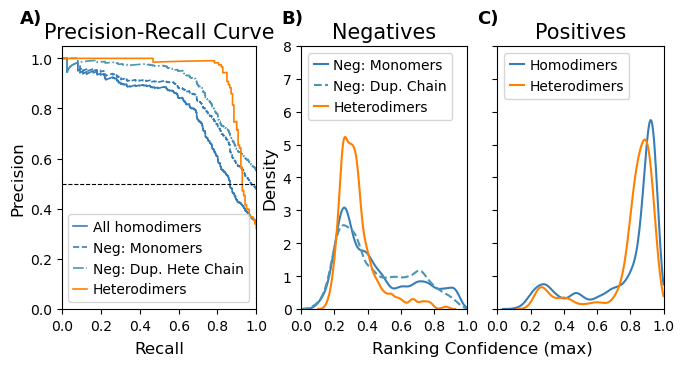

In [32]:
# ── Manuscript figure: PR curve + density plots (3 panels, half A4) ───────────
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

col    = "max_rc"
xlabel = "Ranking Confidence (max)"
bw     = 0.5

# Data slices for density panels
_homo_d    = DATASETS["homodimers"]
_het_cur_d = DATASETS["heterodimers_curated"]

neg_mono = _homo_d[_homo_d["category"] == "monomer"][col]
neg_dup  = _homo_d[_homo_d["category"] == "duplicated_heterodimer_chain"][col]
neg_cur  = _het_cur_d[_het_cur_d["category"] == "hard_negative"][col]

pos_homo = _homo_d[_homo_d["category"] == "homodimer"][col]
pos_hete = _het_cur_d[_het_cur_d["category"] == "heterodimer"][col]

# Font sizes tuned for half-A4 manuscript scale
_fs_title  = 15   # panel titles (not bold)
_fs_label  = 12   # axis labels
_fs_legend = 10
_fs_tick   = 10   # increased; %.1f formatter keeps ticks as 0.0 0.2 … not 0.00 0.25
_legend_kw = dict(fontsize=_fs_legend, handlelength=1.0, handletextpad=0.4)

# Panel A wider than B/C
fig, (ax_pr, ax_neg, ax_pos) = plt.subplots(
    1, 3, figsize=(7.5, 4.0),
    gridspec_kw={"width_ratios": [1.4, 1.2, 1.2]},
)

# ── A: Precision-Recall curve ─────────────────────────────────────────────────
for label, df_sub, color, ls in COMPARISONS:
    vals = df_sub[[col, "correct_result"]]
    prec, rec, _ = precision_recall_curve(vals["correct_result"], vals[col])
    ax_pr.plot(rec, prec, label=f"{label}", color=color, linestyle=ls, linewidth=1.2)
ax_pr.axhline(0.5, linestyle="--", color="k", linewidth=0.8)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)
ax_pr.set_title("Precision-Recall Curve", fontsize=_fs_title)
ax_pr.set_xlabel("")          # label placed below after repositioning
ax_pr.set_ylabel("Precision", fontsize=_fs_label)
ax_pr.tick_params(labelsize=_fs_tick)
ax_pr.xaxis.set_major_locator(MultipleLocator(0.2))
ax_pr.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax_pr.yaxis.set_major_locator(MultipleLocator(0.2))
ax_pr.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax_pr.legend(loc="lower right", **_legend_kw)

# ── B: Density — Negatives ────────────────────────────────────────────────────
_kde = dict(clip=(0, 1), bw_adjust=bw, fill=False, linewidth=1.5)
sns.kdeplot(x=neg_mono, ax=ax_neg, label="Neg: Monomers",        color="#377eb8", linestyle="-",  **_kde)
sns.kdeplot(x=neg_dup,  ax=ax_neg, label="Neg: Dup. Chain",  color="#4a96b0", linestyle="--", **_kde)
sns.kdeplot(x=neg_cur,  ax=ax_neg, label="Heterodimers",          color="#ff7f00", linestyle="-",  **_kde)
ax_neg.set_ylim(0, 8); ax_neg.set_xlim(0, 1)
ax_neg.set_title("Negatives", fontsize=_fs_title)
ax_neg.set_xlabel("")          # shared label placed below after repositioning
ax_neg.set_ylabel("Density", fontsize=_fs_label)
ax_neg.tick_params(labelsize=_fs_tick)
ax_neg.xaxis.set_major_locator(MultipleLocator(0.2))
ax_neg.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax_neg.legend(loc="upper left", **_legend_kw)

# ── C: Density — Positives ────────────────────────────────────────────────────
sns.kdeplot(x=pos_homo, ax=ax_pos, label="Homodimers",   color="#377eb8", linestyle="-", **_kde)
sns.kdeplot(x=pos_hete, ax=ax_pos, label="Heterodimers", color="#ff7f00", linestyle="-", **_kde)
ax_pos.set_ylim(0, 8); ax_pos.set_xlim(0, 1)
ax_pos.set_title("Positives", fontsize=_fs_title)
ax_pos.set_xlabel("")          # shared label placed below after repositioning
ax_pos.set_ylabel("")
ax_pos.tick_params(labelsize=_fs_tick, labelleft=False)
ax_pos.xaxis.set_major_locator(MultipleLocator(0.2))
ax_pos.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax_pos.legend(loc="upper left", **_legend_kw)

# ── Panel labels A), B), C)
_lbl_x, _lbl_y = -0.16, 1.14
ax_pr.text(_lbl_x-0.06, _lbl_y, "A)", transform=ax_pr.transAxes, fontsize=_fs_title - 2, fontweight="bold", va="top")
ax_neg.text(_lbl_x+0.04, _lbl_y, "B)", transform=ax_neg.transAxes, fontsize=_fs_title - 2, fontweight="bold", va="top")
ax_pos.text(_lbl_x+0.04, _lbl_y, "C)", transform=ax_pos.transAxes, fontsize=_fs_title - 2, fontweight="bold", va="top")

# ── Manual gap control (figure-fraction units, ~0.01 ≈ 2 mm at this figsize)
_gap_ab = 0.06   # gap between A and B
_gap_bc = 0.04    # gap between B and C

# tight_layout with extra bottom margin for the shared x-label between B and C
plt.tight_layout(rect=[0, 0.10, 1, 1])
_pos_a = ax_pr.get_position()
_pos_b = ax_neg.get_position()
_pos_c = ax_pos.get_position()
ax_neg.set_position([_pos_a.x1 + _gap_ab, _pos_b.y0, _pos_b.width, _pos_b.height])
_pos_b = ax_neg.get_position()   # re-read after moving B
ax_pos.set_position([_pos_b.x1 + _gap_bc, _pos_c.y0, _pos_c.width, _pos_c.height])
_pos_c = ax_pos.get_position()   # re-read after moving C

# Shared x-label centered between panels B and C
_x_bc = (_pos_b.x0 + _pos_c.x1) / 2
_y_bc = (_pos_b.y0 + _pos_c.y0) / 2 - 0.08
fig.text(_x_bc, _y_bc, xlabel, ha="center", va="top", fontsize=_fs_label)

# x-label for A at the same vertical level
_x_a = (_pos_a.x0 + _pos_a.x1) / 2
fig.text(_x_a, _y_bc, "Recall", ha="center", va="top", fontsize=_fs_label)

save_figure("fig2_manuscript_100726")
plt.show()


## Figure 3 — Foldseek stoichiometry fractions
Requires `category` column.

In [33]:
# ── Figure 3: Foldseek stoichiometry fractions — data ────────────────────────
# Run this cell once (slow: loads 2M-row TSV). Re-run only if data/config changes.
import pickle
import re
from collections import defaultdict
from pathlib import Path

_NB_DIR           = Path("/proj/berzelius-2021-29/users/x_sarna/homomer_project/new_dataset/downstream_analysis")
FOLDSEEK_TSV      = _NB_DIR / "revisionsDataset240626_vs_entirepdb040626_tmalignmode_240626.tsv"

# ─── Load TSV ─────────────────────────────────────────────────────────────────
print("Loading foldseek TSV ...", flush=True)
_tsv = pd.read_csv(FOLDSEEK_TSV, sep="\t", header=None, names=["query", "target", "tm_score"])
_tsv["tm_score"] = pd.to_numeric(_tsv["tm_score"], errors="coerce")
_grouped = {q: g for q, g in _tsv.groupby("query")}
print(f"  {len(_tsv):,} rows, {len(_grouped):,} unique queries", flush=True)


# ─── Group TSV queries by PDB code ────────────────────────────────────────────
_pdb_to_queries = defaultdict(list)
for _q in _grouped:
    _pid = _q.split("-")[0].lower()
    _pdb_to_queries[_pid].append(_q)

Loading foldseek TSV ...
  2,143,503 rows, 3,077 unique queries


In [34]:


# ─── Configuration ────────────────────────────────────────────────────────────

STOICH_CACHE_PATH = "/proj/berzelius-2021-29/users/x_sarna/homomer_project/extract_features_script/foldseek_database/entire_pdb_cache.pkl"
RC_SPLIT          = 0.8

EXCLUDE_SELF    = True
EXCLUDE_PARTNER = False
NO_HITS_POLICY  = "excluded"  # "include_as_zero"

TM_CUTOFFS = [round(x * 0.001, 3) for x in range(1001)]  # 0.00 to 0.99
STOICH_TYPES  = ["monomer", "homomultimer", "heteromultimer"]
STOICH_COLORS = {"monomer": "#377eb8", "homomultimer": "#ff7f0e", "heteromultimer": "#2ca02c"}
STOICH_LABELS = {"monomer": "Monomers", "homomultimer": "Homomultimer", "heteromultimer": "Heteromultimer"}

# ─── Load stoichiometry cache ─────────────────────────────────────────────────
with open(STOICH_CACHE_PATH, "rb") as _fh:
    _stoich_cache = pickle.load(_fh)

# ─── Assembly-base and chain-suffix helpers ───────────────────────────────────
_ASSEM_RE = re.compile(r'^(.+-assembly\d+)(?:_(.*))?$', re.IGNORECASE)

def _assembly_base(s):
    m = _ASSEM_RE.match(s)
    return m.group(1).lower() if m else s.lower()

def _chain_suffix(query):
    m = _ASSEM_RE.match(query)
    return m.group(2) if (m and m.group(2)) else ""

def _stoich_label(target):
    assembly = _assembly_base(target)
    raw = (_stoich_cache.get(assembly) or "unknown").lower()
    if "homo"   in raw: return "homomultimer"
    if "hetero" in raw: return "heteromultimer"
    if raw == "unknown": return "unknown"
    return "monomer"

# ─── Load auth-chain mapping ──────────────────────────────────────────────────
_chain_map_df = pd.read_csv(_NB_DIR / "chain_auth_asym_id_map.csv")

def _auth_chain_id(pdb_code, csv_letter):
    """Return the author chain ID for a given PDB code and CSV chain letter (A/B)."""
    row = _chain_map_df[
        (_chain_map_df["pdbid"] == pdb_code) &
        (_chain_map_df[f"chain_{csv_letter}"] == f"{pdb_code}_{csv_letter}")
    ]
    return row.iloc[0][f"auth_asym_id_{csv_letter}"] if not row.empty else csv_letter

# ─── Build _pdb_to_info keyed by (pdb_code, auth_chain_or_None) ───────────────
_pdb_to_info = {}
for _, _row in DATASETS["homodimers"].iterrows():
    _csv_id  = _row["ID"]
    _cat     = _row.get("category", "unknown")
    _max_rc  = float(_row.get("max_rc", float("nan")))
    _first   = _csv_id.split("-")[0]
    _split   = _first.split("_")
    _pdb     = _split[0].lower()
    if len(_split) > 1 and _cat == "duplicated_heterodimer_chain":
        _chain = _auth_chain_id(_pdb, _split[1])
    else:
        _chain = None
    _pdb_to_info[(_pdb, _chain)] = {"category": _cat, "max_rc": _max_rc}

# ─── Determine the author chain a TSV query corresponds to ────────────────────
# Two cases:
#   1. Query has an explicit chain suffix (e.g. "8xyz-assembly1_C") → use it directly.
#   2. Query has no chain suffix (e.g. "8gjg-assembly1") → find the self-hit: the
#      target with the highest TM within the same assembly tells us which chain this
#      structure was. E.g. target "8gjg-assembly1_A" at TM=1.0 → chain A.
#
# Self-hit exclusion in _process_query works correctly in both cases: _assembly_base
# strips the chain suffix, so "8gjg-assembly1" and "8gjg-assembly1_A" share the same
# base and the self-hit (plus the partner chain) is excluded when EXCLUDE_SELF=True.
def _infer_query_chain(query, group_df):
    q_suffix = _chain_suffix(query)
    if q_suffix:
        return q_suffix
    # No suffix in query name — infer from the self-hit target
    q_base = _assembly_base(query)
    print(f"  Inferring auth chain for query {query} (base {q_base}) ...", flush=True)
    best_chain, best_tm = "", -1.0
    for _, hit in group_df.iterrows():
        if _assembly_base(str(hit["target"])) == q_base:
            tm = float(hit["tm_score"]) if pd.notna(hit["tm_score"]) else 0.0
            if tm > best_tm:
                best_tm    = tm
                best_chain = _chain_suffix(str(hit["target"]))
    return best_chain

# ─── Pick representative TSV queries per (pdb_code, auth_chain_or_None) ────────
# For homodimers/monomers (chain=None): use ALL TSV queries for the PDB so that
# hits from every chain (e.g. _A and _B) are combined before computing fractions.
# For duplicated_heterodimer_chain: only ONE chain per PDB was run in Foldseek.
# Use _infer_query_chain to determine which auth chain each TSV query represents,
# then match it to the correct (pdb, auth_chain) key.
_representative = {}
for (_pdb, _auth_chain) in _pdb_to_info:
    _tsv_queries = _pdb_to_queries.get(_pdb, [])
    if _auth_chain is None:
        if _tsv_queries:
            _representative[(_pdb, None)] = _tsv_queries          # all chain queries
    else:
        for _q in _tsv_queries:
            if _infer_query_chain(_q, _grouped[_q]) == _auth_chain:
                _representative[(_pdb, _auth_chain)] = [_q]        # single chain
                break

# ─── Compute per-query stoichiometry fractions ────────────────────────────────
_records            = []
_self_hit_only_pids = []

def _process_query(key, query, group_df):
    _info = _pdb_to_info[key]
    _excl = {query.split("-")[0].lower()} if EXCLUDE_SELF else set()
    # Deduplicate chain variants within each assembly (e.g. 9x4u-assembly1_A and
    # 9x4u-assembly1_B → one hit per assembly). Different assemblies of the same
    # PDB code (assembly1 vs assembly2) are kept as separate hits and each target
    # protein gets equal weight via fractional PDB-level contributions.
    _best_per_asm = {}
    for _, _hr in group_df.iterrows():
        _t     = str(_hr["target"])
        _t_pdb = _t.split("-")[0].lower()
        if _t_pdb in _excl or not pd.notna(_hr["tm_score"]):
            continue
        _asm = _assembly_base(_t)
        _tm  = float(_hr["tm_score"])
        if _asm not in _best_per_asm or _tm > _best_per_asm[_asm][0]:
            _best_per_asm[_asm] = (_tm, _t_pdb, _stoich_label(_t))
    # list of (tm_score, target_pdb, stoich)
    _asm_hits = list(_best_per_asm.values())
    if not _asm_hits:
        _self_hit_only_pids.append(key)
    for _tm_cut in TM_CUTOFFS:
        # Group passing assemblies by target PDB code for fractional weighting:
        # each unique protein contributes equally regardless of assembly count.
        _pdb_stoichs = {}
        for _tm, _t_pdb, _st in _asm_hits:
            if _tm >= _tm_cut and _st != "unknown":
                if _t_pdb not in _pdb_stoichs:
                    _pdb_stoichs[_t_pdb] = []
                _pdb_stoichs[_t_pdb].append(_st)
        _n_pdbs = len(_pdb_stoichs)
        if _n_pdbs > 0:
            _stoich_sums = {st: 0.0 for st in STOICH_TYPES}
            for _t_pdb, _stoichs in _pdb_stoichs.items():
                _n_asm = len(_stoichs)
                for _st in _stoichs:
                    _stoich_sums[_st] += 1.0 / _n_asm
            for _st in STOICH_TYPES:
                _records.append({"category": _info["category"], "max_rc": _info["max_rc"],
                                  "tm_cutoff": _tm_cut, "stoich": _st,
                                  "frac": _stoich_sums[_st] / _n_pdbs})
        elif NO_HITS_POLICY == "include_as_zero":
            for _st in STOICH_TYPES:
                _records.append({"category": _info["category"], "max_rc": _info["max_rc"],
                                  "tm_cutoff": _tm_cut, "stoich": _st, "frac": 0.0})

for _key, _queries in _representative.items():
    _combined_df = pd.concat([_grouped[_q] for _q in _queries], ignore_index=True)
    _process_query(_key, _queries[0], _combined_df)

_missing = set(_pdb_to_info.keys()) - set(_representative.keys())
if NO_HITS_POLICY == "include_as_zero":
    for _key in _missing:
        _info = _pdb_to_info[_key]
        for _tm_cut in TM_CUTOFFS:
            for _st in STOICH_TYPES:
                _records.append({"category": _info["category"], "max_rc": _info["max_rc"],
                                  "tm_cutoff": _tm_cut, "stoich": _st, "frac": 0.0})

_missing_by_cat = defaultdict(int)
for _key in _missing:
    _missing_by_cat[_pdb_to_info[_key]["category"]] += 1

print(f"  Matched {len(_representative)} queries; "
      f"{len(_self_hit_only_pids)} had only self-hits; "
      f"{len(_missing)} CSV proteins had no TSV hits "
      f"({'included as 0' if NO_HITS_POLICY == 'include_as_zero' else 'excluded'})",
      flush=True)
print(f"  Missing by category: { dict(_missing_by_cat) }", flush=True)
_fracs_df = pd.DataFrame(_records)


KeyboardInterrupt: 

In [12]:
# _self_hit_only_pids
# _missing

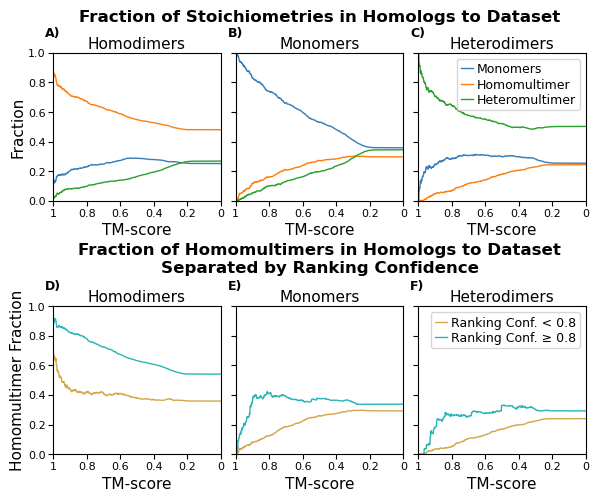

In [ ]:
# ── Figure 3: Foldseek stoichiometry fractions — plot ────────────────────────
# Edit and re-run this cell freely; no need to reload the TSV.
from matplotlib.ticker import FuncFormatter

def plot_stoich_fractions(fracs_df, rc_threshold=RC_SPLIT):
    CAT_ORDER  = ["homodimer", "monomer", "duplicated_heterodimer_chain"]
    CAT_LABELS = {"homodimer": "Homodimers", "monomer": "Monomers",
                  "duplicated_heterodimer_chain": "Heterodimers"}
    cats = [c for c in CAT_ORDER if c in fracs_df["category"].unique()]
    n    = len(cats)

    RC_COLORS = {"low": "#d4a84a", "high": "#2cb5b5"}

    # Font sizes for half-A4 width publication figure
    _fs_sec   = 12.0   # bold section titles
    _fs_title = 11     # panel category titles
    _fs_ax    = 11     # axis labels
    _fs_tick  = 8
    _fs_leg   = 9
    _xlabel_pad = 3    # space between TM-score label and the axis (points)

    # 0.0 → "0", 1.0 → "1", 0.2 → "0.2" — robust to floating-point tick values
    _xtick_fmt = FuncFormatter(lambda x, _: str(int(round(x))) if abs(x - round(x)) < 1e-6 else f"{x:.1f}")

    fig, axes = plt.subplots(2, n, figsize=(4.13, 5.5), sharey="row")
    if n == 1:
        axes = axes.reshape(2, 1)

    plt.subplots_adjust(top=0.84, bottom=0.11, hspace=0.71,
                        left=0.01, right=1.3, wspace=0.09)

    # ── Row 1: all three stoichiometry fractions ──────────────────────────────
    for c, cat in enumerate(cats):
        ax  = axes[0, c]
        sub = fracs_df[fracs_df["category"] == cat]
        for st in STOICH_TYPES:
            means = (sub[sub["stoich"] == st]
                     .groupby("tm_cutoff")["frac"].mean()
                     .reset_index().sort_values("tm_cutoff"))
            ax.plot(means["tm_cutoff"], means["frac"],
                    label=STOICH_LABELS[st], color=STOICH_COLORS[st], linewidth=1.0)
        ax.set_xlim(1.0, 0.0)
        ax.set_ylim(0, 1.0)
        ax.set_xlabel("TM-score", fontsize=_fs_ax, labelpad=_xlabel_pad)
        if c == 0:
            ax.set_ylabel("Fraction", fontsize=_fs_ax, labelpad=2)
        else:
            ax.tick_params(labelleft=False)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
        ax.xaxis.set_major_formatter(_xtick_fmt)
        ax.tick_params(labelsize=_fs_tick, pad=2)
        ax.text(-0.05, 1.09, f"{chr(ord('A') + c)})",
                transform=ax.transAxes, fontsize=_fs_title-2, fontweight="bold",
                va="bottom", ha="left", clip_on=False)
        ax.set_title(CAT_LABELS[cat], fontsize=_fs_title, pad=3)
        if c == n - 1:
            ax.legend(loc="upper right", fontsize=_fs_leg,
                      handlelength=1.0, handletextpad=0.3,
                      borderpad=0.3, labelspacing=0.2)

    # ── Row 2: homomultimer fraction split by ranking confidence ──────────────
    for c, cat in enumerate(cats):
        ax  = axes[1, c]
        sub = fracs_df[fracs_df["category"] == cat]
        for (lbl, mask, color) in [
            (f"Ranking Conf. < {rc_threshold}",  sub["max_rc"] <  rc_threshold, RC_COLORS["low"]),
            (f"Ranking Conf. ≥ {rc_threshold}", sub["max_rc"] >= rc_threshold, RC_COLORS["high"]),
        ]:
            s = sub[mask & (sub["stoich"] == "homomultimer")]
            means = (s.groupby("tm_cutoff")["frac"].mean()
                     .reset_index().sort_values("tm_cutoff"))
            ax.plot(means["tm_cutoff"], means["frac"],
                    label=lbl, color=color, linewidth=1.0)
        ax.set_xlim(1.0, 0.0)
        ax.set_ylim(0, 1.0)
        ax.set_xlabel("TM-score", fontsize=_fs_ax, labelpad=_xlabel_pad)
        if c == 0:
            ax.set_ylabel("Homomultimer Fraction", fontsize=_fs_ax, labelpad=2)
        else:
            ax.tick_params(labelleft=False)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
        ax.xaxis.set_major_formatter(_xtick_fmt)
        ax.tick_params(labelsize=_fs_tick, pad=2)
        ax.text(-0.05, 1.09, f"{chr(ord('D') + c)})",
                transform=ax.transAxes, fontsize=_fs_title-2, fontweight="bold",
                va="bottom", ha="left", clip_on=False)
        ax.set_title(CAT_LABELS[cat], fontsize=_fs_title, pad=3)
        if c == n - 1:
            ax.legend(loc="upper right", fontsize=_fs_leg,
                      handlelength=1.0, handletextpad=0.3,
                      borderpad=0.3, labelspacing=0.2)

    # ── Section titles: centred over the actual plot area ────────────────────
    r1_top = axes[0, 0].get_position().y1
    r1_bot = axes[0, 0].get_position().y0
    r2_top = axes[1, 0].get_position().y1
    x_center = (axes[0, 0].get_position().x0 + axes[0, n - 1].get_position().x1) / 2

    fig.text(x_center, (r1_top + 0.97) / 2,
             "Fraction of Stoichiometries in Homologs to Dataset",
             ha="center", va="center", fontsize=_fs_sec, fontweight="bold")

    _row2_title_shift = 0.01
    fig.text(x_center, (r2_top + r1_bot) / 2 - _row2_title_shift,
             "Fraction of Homomultimers in Homologs to Dataset\nSeparated by Ranking Confidence",
             ha="center", va="center", fontsize=_fs_sec, fontweight="bold")

    save_figure("fig3_stoich_fractions_020726")
    plt.show()

plot_stoich_fractions(_fracs_df)


## Supplementary Figure: Foldseek stoichiometry fractions, split by ranking confidence
Same data (`_fracs_df`) and layout/style as Figure 3. Row 1 is identical to Figure 3's row 1
(all three stoichiometry fractions, all data). Rows 2 and 3 repeat that same panel — all three
stoichiometry fractions, not just homomultimer — restricted to entries with ranking confidence
≥ 0.8 and < 0.8 respectively.

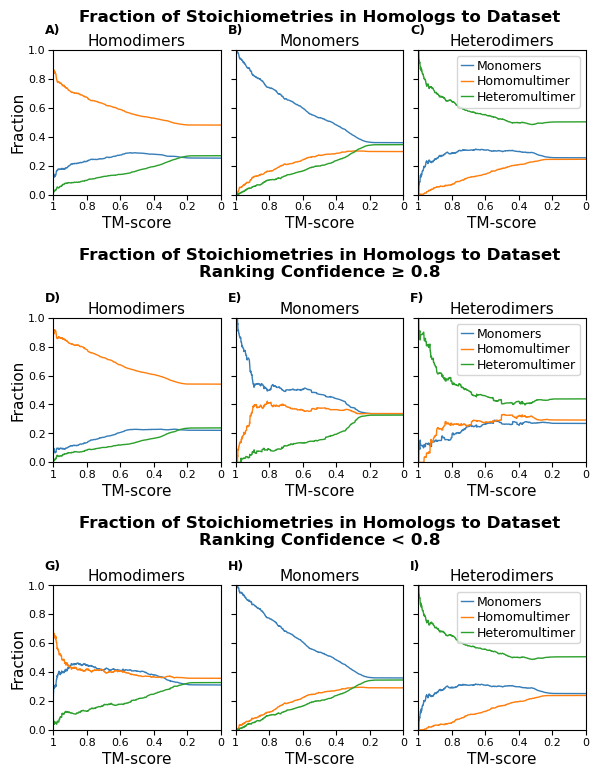

In [14]:
# ── Figure 6: Foldseek stoichiometry fractions — split by ranking confidence ─
# Reuses _fracs_df from the Figure 3 data cell above (re-run that cell first if needed).
# Edit and re-run this cell freely; no need to reload the TSV.

def plot_stoich_fractions_rc_rows(fracs_df, rc_threshold=RC_SPLIT):
    CAT_ORDER  = ["homodimer", "monomer", "duplicated_heterodimer_chain"]
    CAT_LABELS = {"homodimer": "Homodimers", "monomer": "Monomers",
                  "duplicated_heterodimer_chain": "Heterodimers"}
    cats = [c for c in CAT_ORDER if c in fracs_df["category"].unique()]
    n    = len(cats)

    # Font sizes for half-A4 width publication figure (same as Figure 3)
    _fs_sec   = 12.0   # bold section titles
    _fs_title = 11     # panel category titles
    _fs_ax    = 11     # axis labels
    _fs_tick  = 8
    _fs_leg   = 9
    _xlabel_pad = 3    # space between TM-score label and the axis (points)

    # 0.0 → "0", 1.0 → "1", 0.2 → "0.2" — robust to floating-point tick values
    _xtick_fmt = FuncFormatter(lambda x, _: str(int(round(x))) if abs(x - round(x)) < 1e-6 else f"{x:.1f}")

    fig, axes = plt.subplots(3, n, figsize=(4.13, 8.1), sharey="row")
    if n == 1:
        axes = axes.reshape(3, 1)

    plt.subplots_adjust(top=0.90, bottom=0.06, hspace=0.85,
                        left=0.01, right=1.3, wspace=0.09)

    # (row index, subset of fracs_df, first panel-label letter for this row)
    _row_specs = [
        (0, fracs_df,                                   "A"),
        (1, fracs_df[fracs_df["max_rc"] >= rc_threshold], "D"),
        (2, fracs_df[fracs_df["max_rc"] <  rc_threshold], "G"),
    ]

    for r, row_df, letter in _row_specs:
        for c, cat in enumerate(cats):
            ax  = axes[r, c]
            sub = row_df[row_df["category"] == cat]
            for st in STOICH_TYPES:
                means = (sub[sub["stoich"] == st]
                         .groupby("tm_cutoff")["frac"].mean()
                         .reset_index().sort_values("tm_cutoff"))
                ax.plot(means["tm_cutoff"], means["frac"],
                        label=STOICH_LABELS[st], color=STOICH_COLORS[st], linewidth=1.0)
            ax.set_xlim(1.0, 0.0)
            ax.set_ylim(0, 1.0)
            ax.set_xlabel("TM-score", fontsize=_fs_ax, labelpad=_xlabel_pad)
            if c == 0:
                ax.set_ylabel("Fraction", fontsize=_fs_ax, labelpad=2)
            else:
                ax.tick_params(labelleft=False)
            ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
            ax.xaxis.set_major_formatter(_xtick_fmt)
            ax.tick_params(labelsize=_fs_tick, pad=2)
            ax.text(-0.05, 1.09, f"{chr(ord(letter) + c)})",
                    transform=ax.transAxes, fontsize=_fs_title-2, fontweight="bold",
                    va="bottom", ha="left", clip_on=False)
            ax.set_title(CAT_LABELS[cat], fontsize=_fs_title, pad=3)
            if c == n - 1:
                ax.legend(loc="upper right", fontsize=_fs_leg,
                          handlelength=1.0, handletextpad=0.3,
                          borderpad=0.3, labelspacing=0.2)

    # ── Section titles: centred over each row's plot area ─────────────────────
    r1_top = axes[0, 0].get_position().y1
    r1_bot = axes[0, 0].get_position().y0
    r2_top = axes[1, 0].get_position().y1
    r2_bot = axes[1, 0].get_position().y0
    r3_top = axes[2, 0].get_position().y1
    x_center = (axes[0, 0].get_position().x0 + axes[0, n - 1].get_position().x1) / 2

    fig.text(x_center, (r1_top + 0.98) / 2,
             "Fraction of Stoichiometries in Homologs to Dataset",
             ha="center", va="center", fontsize=_fs_sec, fontweight="bold")

    _row_title_shift = 0.01
    fig.text(x_center, (r2_top + r1_bot) / 2 - _row_title_shift,
             f"Fraction of Stoichiometries in Homologs to Dataset\nRanking Confidence ≥ {rc_threshold}",
             ha="center", va="center", fontsize=_fs_sec, fontweight="bold")

    fig.text(x_center, (r3_top + r2_bot) / 2 - _row_title_shift,
             f"Fraction of Stoichiometries in Homologs to Dataset\nRanking Confidence < {rc_threshold}",
             ha="center", va="center", fontsize=_fs_sec, fontweight="bold")

    save_figure("figS2_stoich_fractions_rc_split_100726")
    plt.show()

plot_stoich_fractions_rc_rows(_fracs_df)


In [15]:
# # ── Figure 4: Foldseek stoichiometry fractions — homodimers dataset ───────────
# # Uses precomputed multimer_frac_tm* and hm_frac_tm* columns from the CSV.
# from matplotlib.ticker import FuncFormatter

# _RC_SPLIT_HOM = 0.8
# _HOM_DF = DATASETS["homodimers"].copy()

# # TM cutoffs encoded in the column names (0.0 to 0.9)
# _HOM_TM_VALS = [round(x * 0.1, 1) for x in range(10)]

# # Melt to long format
# _hom_records = []
# for _, _row in _HOM_DF.iterrows():
#     _cat = _row["category"]
#     _rc  = float(_row.get("max_rc", float("nan")))
#     for _tm in _HOM_TM_VALS:
#         _hom_records.append({
#             "category":      _cat,
#             "max_rc":        _rc,
#             "tm_cutoff":     _tm,
#             "multimer_frac": float(_row[f"multimer_frac_tm{_tm}"]),
#             "hm_frac":       float(_row[f"hm_frac_tm{_tm}"]),
#         })
# _hom_fracs_df = pd.DataFrame(_hom_records)

# # ── Plot ──────────────────────────────────────────────────────────────────────
# CAT_ORDER_HOM  = ["homodimer", "monomer", "duplicated_heterodimer_chain"]
# CAT_LABELS_HOM = {"homodimer": "Homodimers", "monomer": "Monomers",
#                   "duplicated_heterodimer_chain": "Heteromers"}
# cats_hom = [c for c in CAT_ORDER_HOM if c in _hom_fracs_df["category"].unique()]
# n_hom    = len(cats_hom)

# _FRAC_COLORS   = {"multimer_frac": "#e41a1c", "hm_frac": "#ff7f0e"}
# _FRAC_LABELS   = {"multimer_frac": "Multimer frac.", "hm_frac": "Homomultimer frac."}
# _RC_COLORS_HOM = {"low": "#d4a84a", "high": "#2cb5b5"}

# _fs_sec_h     = 12.0
# _fs_title_h   = 11
# _fs_ax_h      = 11
# _fs_tick_h    = 8
# _fs_leg_h     = 9
# _xlabel_pad_h = 3
# _xtick_fmt_h  = FuncFormatter(lambda x, _: str(int(round(x))) if abs(x - round(x)) < 1e-6 else f"{x:.1f}")

# fig_hom, axes_hom = plt.subplots(3, n_hom, figsize=(4.13, 7.5), sharey="row")
# if n_hom == 1:
#     axes_hom = axes_hom.reshape(3, 1)

# plt.subplots_adjust(top=0.88, bottom=0.07, hspace=0.75,
#                     left=0.01, right=1.3, wspace=0.09)

# # ── Row 1: multimer_frac and hm_frac ─────────────────────────────────────────
# for c, cat in enumerate(cats_hom):
#     ax  = axes_hom[0, c]
#     sub = _hom_fracs_df[_hom_fracs_df["category"] == cat]
#     for frac_col in ["multimer_frac", "hm_frac"]:
#         means = (sub.groupby("tm_cutoff")[frac_col].mean()
#                  .reset_index().sort_values("tm_cutoff"))
#         ax.plot(means["tm_cutoff"], means[frac_col],
#                 label=_FRAC_LABELS[frac_col], color=_FRAC_COLORS[frac_col], linewidth=1.0)
#     ax.set_xlim(1.0, 0.0); ax.set_ylim(0, 1.0)
#     ax.set_xlabel("TM-score", fontsize=_fs_ax_h, labelpad=_xlabel_pad_h)
#     ax.set_ylabel("Fraction", fontsize=_fs_ax_h, labelpad=2) if c == 0 else ax.tick_params(labelleft=False)
#     ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
#     ax.xaxis.set_major_formatter(_xtick_fmt_h)
#     ax.tick_params(labelsize=_fs_tick_h, pad=2)
#     ax.text(-0.05, 1.08, f"{chr(ord('A') + c)})",
#             transform=ax.transAxes, fontsize=_fs_title_h - 2, fontweight="bold",
#             va="bottom", ha="left", clip_on=False)
#     ax.set_title(CAT_LABELS_HOM[cat], fontsize=_fs_title_h, pad=3)
#     if c == n_hom - 1:
#         ax.legend(loc="upper right", fontsize=_fs_leg_h,
#                   handlelength=1.0, handletextpad=0.3, borderpad=0.3, labelspacing=0.2)

# # ── Row 2: multimer_frac split by ranking confidence ─────────────────────────
# for c, cat in enumerate(cats_hom):
#     ax  = axes_hom[1, c]
#     sub = _hom_fracs_df[_hom_fracs_df["category"] == cat]
#     for lbl, mask, color in [
#         (f"RC < {_RC_SPLIT_HOM}",  sub["max_rc"] <  _RC_SPLIT_HOM, _RC_COLORS_HOM["low"]),
#         (f"RC ≥ {_RC_SPLIT_HOM}", sub["max_rc"] >= _RC_SPLIT_HOM, _RC_COLORS_HOM["high"]),
#     ]:
#         means = (sub[mask].groupby("tm_cutoff")["multimer_frac"].mean()
#                  .reset_index().sort_values("tm_cutoff"))
#         ax.plot(means["tm_cutoff"], means["multimer_frac"],
#                 label=lbl, color=color, linewidth=1.0)
#     ax.set_xlim(1.0, 0.0); ax.set_ylim(0, 1.0)
#     ax.set_xlabel("TM-score", fontsize=_fs_ax_h, labelpad=_xlabel_pad_h)
#     ax.set_ylabel("Multimer Fraction", fontsize=_fs_ax_h, labelpad=2) if c == 0 else ax.tick_params(labelleft=False)
#     ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
#     ax.xaxis.set_major_formatter(_xtick_fmt_h)
#     ax.tick_params(labelsize=_fs_tick_h, pad=2)
#     ax.text(-0.05, 1.09, f"{chr(ord('D') + c)})",
#             transform=ax.transAxes, fontsize=_fs_title_h - 2, fontweight="bold",
#             va="bottom", ha="left", clip_on=False)
#     ax.set_title(CAT_LABELS_HOM[cat], fontsize=_fs_title_h, pad=3)
#     if c == n_hom - 1:
#         ax.legend(loc="upper right", fontsize=_fs_leg_h,
#                   handlelength=1.0, handletextpad=0.3, borderpad=0.3, labelspacing=0.2)

# # ── Row 3: hm_frac split by ranking confidence ───────────────────────────────
# for c, cat in enumerate(cats_hom):
#     ax  = axes_hom[2, c]
#     sub = _hom_fracs_df[_hom_fracs_df["category"] == cat]
#     for lbl, mask, color in [
#         (f"RC < {_RC_SPLIT_HOM}",  sub["max_rc"] <  _RC_SPLIT_HOM, _RC_COLORS_HOM["low"]),
#         (f"RC ≥ {_RC_SPLIT_HOM}", sub["max_rc"] >= _RC_SPLIT_HOM, _RC_COLORS_HOM["high"]),
#     ]:
#         means = (sub[mask].groupby("tm_cutoff")["hm_frac"].mean()
#                  .reset_index().sort_values("tm_cutoff"))
#         ax.plot(means["tm_cutoff"], means["hm_frac"],
#                 label=lbl, color=color, linewidth=1.0)
#     ax.set_xlim(1.0, 0.0); ax.set_ylim(0, 1.0)
#     ax.set_xlabel("TM-score", fontsize=_fs_ax_h, labelpad=_xlabel_pad_h)
#     ax.set_ylabel("Homomultimer Fraction", fontsize=_fs_ax_h, labelpad=2) if c == 0 else ax.tick_params(labelleft=False)
#     ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
#     ax.xaxis.set_major_formatter(_xtick_fmt_h)
#     ax.tick_params(labelsize=_fs_tick_h, pad=2)
#     ax.text(-0.05, 1.09, f"{chr(ord('G') + c)})",
#             transform=ax.transAxes, fontsize=_fs_title_h - 2, fontweight="bold",
#             va="bottom", ha="left", clip_on=False)
#     ax.set_title(CAT_LABELS_HOM[cat], fontsize=_fs_title_h, pad=3)
#     if c == n_hom - 1:
#         ax.legend(loc="upper right", fontsize=_fs_leg_h,
#                   handlelength=1.0, handletextpad=0.3, borderpad=0.3, labelspacing=0.2)

# # ── Section titles centred over the plot area ─────────────────────────────────
# _r1_top_h = axes_hom[0, 0].get_position().y1
# _r2_top_h = axes_hom[1, 0].get_position().y1
# _r2_bot_h = axes_hom[1, 0].get_position().y0
# _r3_top_h = axes_hom[2, 0].get_position().y1
# _r3_bot_h = axes_hom[2, 0].get_position().y0
# _x_center_h = (axes_hom[0, 0].get_position().x0 + axes_hom[0, n_hom - 1].get_position().x1) / 2

# fig_hom.text(_x_center_h, (_r1_top_h + 0.97) / 2,
#              "Fraction of Multimers in Homologs to Dataset",
#              ha="center", va="center", fontsize=_fs_sec_h, fontweight="bold")

# fig_hom.text(_x_center_h, (_r2_top_h + _r2_bot_h) / 2 + 0.03,
#              "Multimer Fraction in Homologs\nSeparated by Ranking Confidence",
#              ha="center", va="bottom", fontsize=_fs_sec_h, fontweight="bold")

# fig_hom.text(_x_center_h, (_r3_top_h + _r3_bot_h) / 2 + 0.03,
#              "Homomultimer Fraction in Homologs\nSeparated by Ranking Confidence",
#              ha="center", va="bottom", fontsize=_fs_sec_h, fontweight="bold")

# save_figure("figS1_hom_stoich_fractions")
# plt.show()


Loading MMseqs TSV ...


  189,339 rows, 2,139 unique queries
  122 CSV entries had no MMseqs query
  Categories in data: ['homodimer', 'monomer', 'duplicated_heterodimer_chain']


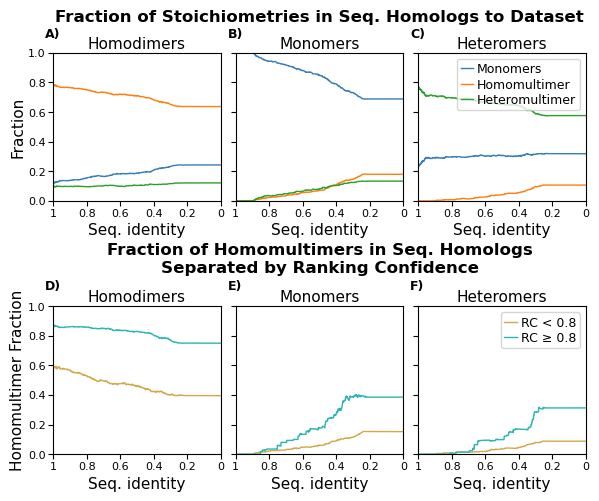

In [16]:
# ── Figure 5: MMseqs stoichiometry fractions — homodimers dataset ─────────────
# Analogous to Figure 3 but using MMseqs sequence identity instead of TM-score.
# Queries are in pdbid_chain format (e.g. "9g04_A"), but CSV IDs for homodimers
# and monomers are pdbcode-pdbcode (no chain), so we build a pdb→query mapping.
import pickle, re
from pathlib import Path
from matplotlib.ticker import FuncFormatter

_MM_NB_DIR = Path("/proj/berzelius-2021-29/users/x_sarna/homomer_project/new_dataset/downstream_analysis")
_MM_TSV    = _MM_NB_DIR / "mmseqs_revisionsDataset240626_vs_entirepdb040626_250626.m8"
_MM_RC_SPLIT     = 0.8
_MM_FIDENT_CUTS  = [round(x * 0.001, 3) for x in range(1000)]   # 0.00 to 0.99
_MM_STOICH_TYPES = ["monomer", "homomultimer", "heteromultimer"]

# Reuse stoichiometry cache if already loaded by the Foldseek data cell
try:
    _mm_stoich_cache = _stoich_cache
except NameError:
    _MM_CACHE_PATH = ("/proj/berzelius-2021-29/users/x_sarna/homomer_project"
                     "/extract_features_script/foldseek_database/entire_pdb_cache.pkl")
    with open(_MM_CACHE_PATH, "rb") as _fh:
        _mm_stoich_cache = pickle.load(_fh)

_MM_ASSEM_RE = re.compile(r'^(.+-assembly\d+)(?:_(.*))?$', re.IGNORECASE)

def _mm_asm_base(s):
    m = _MM_ASSEM_RE.match(s)
    return m.group(1).lower() if m else s.lower()

def _mm_stoich(target):
    raw = (_mm_stoich_cache.get(_mm_asm_base(target)) or "unknown").lower()
    if "homo"   in raw: return "homomultimer"
    if "hetero" in raw: return "heteromultimer"
    if raw == "unknown": return "unknown"
    return "monomer"

# ─── Load MMseqs TSV ──────────────────────────────────────────────────────────
print("Loading MMseqs TSV ...", flush=True)
_mm_tsv = pd.read_csv(_MM_TSV, sep="\t", header=None, names=["query", "target", "fident"])
_mm_tsv["fident"] = pd.to_numeric(_mm_tsv["fident"], errors="coerce")
_mm_grouped = {q: g for q, g in _mm_tsv.groupby("query")}
print(f"  {len(_mm_tsv):,} rows, {len(_mm_grouped):,} unique queries", flush=True)

# ─── PDB code → MMseqs queries mapping ────────────────────────────────────────
# CSV homodimer/monomer IDs are "pdbcode-pdbcode" (no chain), but MMseqs queries
# are "pdbcode_chain". Map each pdbcode → all matching queries (e.g. both _A and _B).
_mm_pdb_to_queries = {}
for _q in _mm_grouped:
    _pdb = _q.split("_")[0].lower()
    _mm_pdb_to_queries.setdefault(_pdb, []).append(_q)

# ─── Compute per-entry fractions ──────────────────────────────────────────────
_mm_records = []
_mm_missing  = 0

for _, _row in DATASETS["homodimers"].iterrows():
    _cat    = _row["category"]
    _max_rc = float(_row.get("max_rc", float("nan")))
    _first  = str(_row["ID"]).split("-")[0]

    if "_" in _first:
        # duplicated_heterodimer_chain format: "7wdk_A" — chain is explicit
        _q_pdb   = _first.split("_")[0].lower()
        _qnames  = [_first] if _first in _mm_grouped else []
    else:
        # homodimer/monomer format: "9g04" — use ALL matching MMseqs queries
        _q_pdb  = _first.lower()
        _qnames = [_q for _q in _mm_pdb_to_queries.get(_q_pdb, []) if _q in _mm_grouped]

    if not _qnames:
        _mm_missing += 1
        continue

    # Pool hits from all chain queries; keep best fident per target assembly.
    # Different assemblies of the same PDB code are kept as separate hits;
    # fractional weighting ensures each unique target protein contributes equally.
    _best_mm = {}
    for _qname in _qnames:
        for _, _hr in _mm_grouped[_qname].iterrows():
            _t     = str(_hr["target"])
            _t_pdb = _t.split("-")[0].lower()
            if _t_pdb == _q_pdb:
                continue
            _asm = _mm_asm_base(_t)
            _fv  = float(_hr["fident"])
            if _asm not in _best_mm or _fv > _best_mm[_asm][0]:
                _best_mm[_asm] = (_fv, _t_pdb, _mm_stoich(_t))
    _asm_mm_hits = list(_best_mm.values())   # (fident, target_pdb, stoich)

    for _fi in _MM_FIDENT_CUTS:
        _pdb_stoichs_mm = {}
        for _fv, _t_pdb, _st in _asm_mm_hits:
            if _fv >= _fi and _st != "unknown":
                if _t_pdb not in _pdb_stoichs_mm:
                    _pdb_stoichs_mm[_t_pdb] = []
                _pdb_stoichs_mm[_t_pdb].append(_st)
        _n_pdbs_mm = len(_pdb_stoichs_mm)
        if _n_pdbs_mm > 0:
            _stoich_sums_mm = {st: 0.0 for st in _MM_STOICH_TYPES}
            for _t_pdb, _stoichs in _pdb_stoichs_mm.items():
                _n_asm = len(_stoichs)
                for _st in _stoichs:
                    _stoich_sums_mm[_st] += 1.0 / _n_asm
            for _st in _MM_STOICH_TYPES:
                _mm_records.append({"category": _cat, "max_rc": _max_rc,
                                    "fident_cutoff": _fi, "stoich": _st,
                                    "frac": _stoich_sums_mm[_st] / _n_pdbs_mm})

print(f"  {_mm_missing} CSV entries had no MMseqs query", flush=True)
_mm_fracs_df = pd.DataFrame(_mm_records)
print(f"  Categories in data: {_mm_fracs_df['category'].unique().tolist()}", flush=True)

# ── Plot (same layout as Figure 3) ───────────────────────────────────────────
_MM_STOICH_COLORS = {"monomer": "#377eb8", "homomultimer": "#ff7f0e", "heteromultimer": "#2ca02c"}
_MM_STOICH_LABELS = {"monomer": "Monomers", "homomultimer": "Homomultimer", "heteromultimer": "Heteromultimer"}
_MM_CAT_ORDER  = ["homodimer", "monomer", "duplicated_heterodimer_chain"]
_MM_CAT_LABELS = {"homodimer": "Homodimers", "monomer": "Monomers",
                  "duplicated_heterodimer_chain": "Heteromers"}
_mm_cats  = [c for c in _MM_CAT_ORDER if c in _mm_fracs_df["category"].unique()]
_n_mm     = len(_mm_cats)
_MM_RC_COLORS = {"low": "#d4a84a", "high": "#2cb5b5"}

_fs_sec_m = 12.0; _fs_title_m = 11; _fs_ax_m = 11
_fs_tick_m = 8;   _fs_leg_m   = 9;  _xlabel_pad_m = 3
_xtick_fmt_m = FuncFormatter(lambda x, _: str(int(round(x))) if abs(x - round(x)) < 1e-6 else f"{x:.1f}")

fig_mm, axes_mm = plt.subplots(2, _n_mm, figsize=(4.13, 5.5), sharey="row")
if _n_mm == 1:
    axes_mm = axes_mm.reshape(2, 1)
plt.subplots_adjust(top=0.84, bottom=0.11, hspace=0.71,
                    left=0.01, right=1.3, wspace=0.09)

# ── Row 1: all stoichiometry fractions ───────────────────────────────────────
for c, cat in enumerate(_mm_cats):
    ax  = axes_mm[0, c]
    sub = _mm_fracs_df[_mm_fracs_df["category"] == cat]
    for st in _MM_STOICH_TYPES:
        means = (sub[sub["stoich"] == st]
                 .groupby("fident_cutoff")["frac"].mean()
                 .reset_index().sort_values("fident_cutoff"))
        ax.plot(means["fident_cutoff"], means["frac"],
                label=_MM_STOICH_LABELS[st], color=_MM_STOICH_COLORS[st], linewidth=1.0)
    ax.set_xlim(1.0, 0.0); ax.set_ylim(0, 1.0)
    ax.set_xlabel("Seq. identity", fontsize=_fs_ax_m, labelpad=_xlabel_pad_m)
    ax.set_ylabel("Fraction", fontsize=_fs_ax_m, labelpad=2) if c == 0 else ax.tick_params(labelleft=False)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.xaxis.set_major_formatter(_xtick_fmt_m)
    ax.tick_params(labelsize=_fs_tick_m, pad=2)
    ax.text(-0.05, 1.08, f"{chr(ord('A') + c)})",
            transform=ax.transAxes, fontsize=_fs_title_m - 2, fontweight="bold",
            va="bottom", ha="left", clip_on=False)
    ax.set_title(_MM_CAT_LABELS[cat], fontsize=_fs_title_m, pad=3)
    if c == _n_mm - 1:
        ax.legend(loc="upper right", fontsize=_fs_leg_m,
                  handlelength=1.0, handletextpad=0.3, borderpad=0.3, labelspacing=0.2)

# ── Row 2: homomultimer fraction split by ranking confidence ─────────────────
for c, cat in enumerate(_mm_cats):
    ax  = axes_mm[1, c]
    sub = _mm_fracs_df[_mm_fracs_df["category"] == cat]
    for lbl, mask, color in [
        (f"RC < {_MM_RC_SPLIT}",  sub["max_rc"] <  _MM_RC_SPLIT, _MM_RC_COLORS["low"]),
        (f"RC ≥ {_MM_RC_SPLIT}", sub["max_rc"] >= _MM_RC_SPLIT, _MM_RC_COLORS["high"]),
    ]:
        s     = sub[mask & (sub["stoich"] == "homomultimer")]
        means = (s.groupby("fident_cutoff")["frac"].mean()
                 .reset_index().sort_values("fident_cutoff"))
        ax.plot(means["fident_cutoff"], means["frac"],
                label=lbl, color=color, linewidth=1.0)
    ax.set_xlim(1.0, 0.0); ax.set_ylim(0, 1.0)
    ax.set_xlabel("Seq. identity", fontsize=_fs_ax_m, labelpad=_xlabel_pad_m)
    ax.set_ylabel("Homomultimer Fraction", fontsize=_fs_ax_m, labelpad=2) if c == 0 else ax.tick_params(labelleft=False)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.xaxis.set_major_formatter(_xtick_fmt_m)
    ax.tick_params(labelsize=_fs_tick_m, pad=2)
    ax.text(-0.05, 1.09, f"{chr(ord('D') + c)})",
            transform=ax.transAxes, fontsize=_fs_title_m - 2, fontweight="bold",
            va="bottom", ha="left", clip_on=False)
    ax.set_title(_MM_CAT_LABELS[cat], fontsize=_fs_title_m, pad=3)
    if c == _n_mm - 1:
        ax.legend(loc="upper right", fontsize=_fs_leg_m,
                  handlelength=1.0, handletextpad=0.3, borderpad=0.3, labelspacing=0.2)

# ── Section titles ────────────────────────────────────────────────────────────
_mm_r1_top = axes_mm[0, 0].get_position().y1
_mm_r1_bot = axes_mm[0, 0].get_position().y0
_mm_r2_top = axes_mm[1, 0].get_position().y1
_mm_x_ctr  = (axes_mm[0, 0].get_position().x0 + axes_mm[0, _n_mm - 1].get_position().x1) / 2

fig_mm.text(_mm_x_ctr, (_mm_r1_top + 0.97) / 2,
            "Fraction of Stoichiometries in Seq. Homologs to Dataset",
            ha="center", va="center", fontsize=_fs_sec_m, fontweight="bold")

fig_mm.text(_mm_x_ctr, (_mm_r2_top + _mm_r1_bot) / 2 - 0.01,
            "Fraction of Homomultimers in Seq. Homologs\nSeparated by Ranking Confidence",
            ha="center", va="center", fontsize=_fs_sec_m, fontweight="bold")

save_figure("figS1_mmseqs_stoich_fractions_100726")
plt.show()


In [17]:
# # Analyze mmseqs results a bit further
# # At Fident 1.0 answer questions: 
# # How many queries have hits for each of the categories (homodimers, monomers, heterodimers)? 
# # What is there distribution of stoichiometries? And how many hits in monomers/homomultimers/heteromultimers are there for each of the categories?

_FIDENT_THRESH = 0.9
_CAT_LABELS_MM = {"homodimer": "Homodimers", "monomer": "Monomers",
                  "duplicated_heterodimer_chain": "Heteromers"}

print(f"MMseqs hits at fident = {_FIDENT_THRESH}:")

for _cat in ["homodimer", "monomer", "duplicated_heterodimer_chain"]:
    _n_queries_total     = 0
    _n_queries_with_hits = 0
    _hit_stoichs         = []   # one entry per target assembly
    # stoich → {query_pdb: [target_assembly, ...]}
    _hits_by_stoich = {st: {} for st in _MM_STOICH_TYPES}

    for _, _row in DATASETS["homodimers"].iterrows():
        if _row.get("category") != _cat:
            continue
        _first = str(_row["ID"]).split("-")[0]
        if "_" in _first:
            _q_pdb  = _first.split("_")[0].lower()
            _qnames = [_first] if _first in _mm_grouped else []
        else:
            _q_pdb  = _first.lower()
            _qnames = [_q for _q in _mm_pdb_to_queries.get(_q_pdb, []) if _q in _mm_grouped]
        if not _qnames:
            continue
        _n_queries_total += 1

        # Pool hits from all chain queries; keep best fident per target assembly.
        _best = {}
        for _qname in _qnames:
            for _, _hr in _mm_grouped[_qname].iterrows():
                _t     = str(_hr["target"])
                _t_pdb = _t.split("-")[0].lower()
                if _t_pdb == _q_pdb:
                    continue
                _fv = float(_hr["fident"])
                if _fv < _FIDENT_THRESH:
                    continue
                _asm = _mm_asm_base(_t)
                if _asm not in _best or _fv > _best[_asm][0]:
                    _best[_asm] = (_fv, _mm_stoich(_t))

        if _best:
            _n_queries_with_hits += 1
            for _asm, (_fv, _st) in _best.items():
                if _st != "unknown":
                    _hit_stoichs.append(_st)
                    _hits_by_stoich[_st].setdefault(_q_pdb, []).append(_asm)

    _n_hits = len(_hit_stoichs)
    print(f"\n{_CAT_LABELS_MM[_cat]}:")
    print(f"  Queries with hits: {_n_queries_with_hits} / {_n_queries_total}")
    print(f"  Total hit assemblies: {_n_hits}")
    if _n_hits > 0:
        for _st in _MM_STOICH_TYPES:
            _c = _hit_stoichs.count(_st)
            print(f"    {100*_c/_n_hits:.1f}%  {_MM_STOICH_LABELS[_st]} (n={_c})")

    if _cat == "monomer":
        for _st in ["homomultimer", "heteromultimer"]:
            if _hits_by_stoich[_st]:
                print(f"  Monomer queries with {_MM_STOICH_LABELS[_st]} hits:")
                for _qid, _asms in sorted(_hits_by_stoich[_st].items()):
                    print(f"    {_qid}: {_asms}")
    elif _cat == "duplicated_heterodimer_chain":
        if _hits_by_stoich["homomultimer"]:
            print(f"  Heteromer queries with homomultimer hits:")
            for _qid, _asms in sorted(_hits_by_stoich["homomultimer"].items()):
                print(f"    {_qid}: {_asms}")


MMseqs hits at fident = 0.9:



Homodimers:
  Queries with hits: 420 / 716
  Total hit assemblies: 1799
    18.6%  Monomers (n=335)
    70.7%  Homomultimer (n=1272)
    10.7%  Heteromultimer (n=192)

Monomers:
  Queries with hits: 311 / 783
  Total hit assemblies: 1154
    100.0%  Monomers (n=1154)
    0.0%  Homomultimer (n=0)
    0.0%  Heteromultimer (n=0)

Heteromers:
  Queries with hits: 247 / 462
  Total hit assemblies: 1054
    23.2%  Monomers (n=245)
    0.0%  Homomultimer (n=0)
    76.8%  Heteromultimer (n=809)


In [18]:
# Analyze Foldseek results a bit further
# At TM-score threshold: how many queries have hits for each category,
# what is the stoichiometry distribution, and which queries have unexpected stoichiometry hits?

_FS_THRESH     = 0.8
_FS_CAT_LABELS = {"homodimer": "Homodimers", "monomer": "Monomers",
                  "duplicated_heterodimer_chain": "Heteromers"}

print(f"Foldseek hits at TM-score >= {_FS_THRESH}:")

for _fs_cat in ["homodimer", "monomer", "duplicated_heterodimer_chain"]:
    _fs_n_total      = 0
    _fs_n_with_hits  = 0
    _fs_hit_stoichs  = []   # one entry per target assembly
    # stoich → {query_pdb: [target_assembly, ...]}
    _fs_hits_by_stoich = {st: {} for st in STOICH_TYPES}

    for _, _row in DATASETS["homodimers"].iterrows():
        if _row.get("category") != _fs_cat:
            continue
        _first = str(_row["ID"]).split("-")[0]
        if "_" in _first:
            _fs_q_pdb  = _first.split("_")[0].lower()
            _fs_qnames = [_q for _q in _pdb_to_queries.get(_fs_q_pdb, []) if _q in _grouped
                          and _chain_suffix(_q) == _first.split("_")[1]]
        else:
            _fs_q_pdb  = _first.lower()
            _fs_qnames = [_q for _q in _pdb_to_queries.get(_fs_q_pdb, []) if _q in _grouped]
        if not _fs_qnames:
            continue
        _fs_n_total += 1

        # Pool hits from all chain queries; keep best TM per target assembly.
        _fs_best = {}
        for _fs_q in _fs_qnames:
            for _, _hr in _grouped[_fs_q].iterrows():
                _t     = str(_hr["target"])
                _t_pdb = _t.split("-")[0].lower()
                if _t_pdb == _fs_q_pdb:
                    continue
                _tm = _hr["tm_score"]
                if not pd.notna(_tm) or float(_tm) < _FS_THRESH:
                    continue
                _asm = _assembly_base(_t)
                _tmf = float(_tm)
                if _asm not in _fs_best or _tmf > _fs_best[_asm][0]:
                    _fs_best[_asm] = (_tmf, _stoich_label(_t))

        if _fs_best:
            _fs_n_with_hits += 1
            for _asm, (_tmf, _st) in _fs_best.items():
                if _st != "unknown":
                    _fs_hit_stoichs.append(_st)
                    _fs_hits_by_stoich[_st].setdefault(_fs_q_pdb, []).append(_asm)

    _fs_n_hits = len(_fs_hit_stoichs)
    print(f"\n{_FS_CAT_LABELS[_fs_cat]}:")
    print(f"  Queries with hits: {_fs_n_with_hits} / {_fs_n_total}")
    print(f"  Total hit assemblies: {_fs_n_hits}")
    if _fs_n_hits > 0:
        for _st in STOICH_TYPES:
            _c = _fs_hit_stoichs.count(_st)
            print(f"    {100*_c/_fs_n_hits:.1f}%  {STOICH_LABELS[_st]} (n={_c})")

    if _fs_cat == "monomer":
        for _st in ["homomultimer", "heteromultimer"]:
            if _fs_hits_by_stoich[_st]:
                print(f"  Monomer queries with {STOICH_LABELS[_st]} hits:")
                for _qid, _asms in sorted(_fs_hits_by_stoich[_st].items()):
                    print(f"    {_qid}: {_asms}")
    elif _fs_cat == "duplicated_heterodimer_chain":
        if _fs_hits_by_stoich["homomultimer"]:
            print(f"  Heteromer queries with homomultimer hits:")
            for _qid, _asms in sorted(_fs_hits_by_stoich["homomultimer"].items()):
                print(f"    {_qid}: {_asms}")


Foldseek hits at TM-score >= 0.8:

Homodimers:
  Queries with hits: 633 / 712
  Total hit assemblies: 54215
    29.3%  Monomers (n=15878)
    59.9%  Homomultimer (n=32469)
    10.8%  Heteromultimer (n=5868)

Monomers:
  Queries with hits: 30 / 34
  Total hit assemblies: 1019
    77.6%  Monomers (n=791)
    7.3%  Homomultimer (n=74)
    15.1%  Heteromultimer (n=154)
  Monomer queries with Homomultimer hits:
    7vfr: ['2z8f-assembly3', '2z8e-assembly3', '2z8d-assembly3', '7c69-assembly1', '7c66-assembly1', '7c68-assembly1', '7c6g-assembly1', '7c67-assembly1', '7c64-assembly1', '7c6i-assembly1']
    7vu3: ['3t24-assembly4', '3t20-assembly2']
    8b97: ['4i4r-assembly2', '4i4o-assembly1', '4i4p-assembly1', '4i4r-assembly1', '4i4u-assembly1', '4i4x-assembly2', '4i4s-assembly2', '4i4y-assembly1', '4i4u-assembly2', '4i4s-assembly1', '4i4x-assembly1', '4i4v-assembly1', '4i4v-assembly2', '4i4y-assembly2', '4i4q-assembly1']
    8bjo: ['7c8g-assembly1', '7c8f-assembly1']
    8ch3: ['4ra1-assembl

In [19]:
# ── Build MMseqs fident lookup: (query_pdb, target_pdb) → max seq. identity ──────
print('Building sequence-identity lookup from MMseqs data...', flush=True)
_mm_q_pdb = _mm_tsv['query'].str.split('_', n=1).str[0].str.lower()
_mm_t_pdb = _mm_tsv['target'].str.split('-', n=1).str[0].str.lower()
_fi_lookup = (
    pd.DataFrame({'q_pdb': _mm_q_pdb, 't_pdb': _mm_t_pdb, 'fident': _mm_tsv['fident']})
    .groupby(['q_pdb', 't_pdb'])['fident'].max()
    .to_dict()
)
print(f'  {len(_fi_lookup):,} (query_pdb, target_pdb) pairs', flush=True)


Building sequence-identity lookup from MMseqs data...
  85,591 (query_pdb, target_pdb) pairs


Foldseek hits at TM >= 0.999: 270 hits (270 with MMseqs seq. identity)

Supplementary Table — stoichiometry of structural homologs at TM >= 0.999:


,Category,Stoichiometry,Fraction,N hits,Median seq. id.,Mean seq. id.
0,Homodimers,Monomer,0.183,22,1.0,0.998
1,Homodimers,Homomultimer,0.808,97,1.0,0.997
2,Homodimers,Heteromultimer,0.008,1,1.0,1.000
3,Monomers,Monomer,1.000,77,1.0,0.998
4,Monomers,Homomultimer,0.000,0,NaN,NaN
5,Monomers,Heteromultimer,0.000,0,NaN,NaN
6,Heteromers,Monomer,0.027,2,1.0,1.000
7,Heteromers,Homomultimer,0.000,0,NaN,NaN
8,Heteromers,Heteromultimer,0.973,71,1.0,0.991


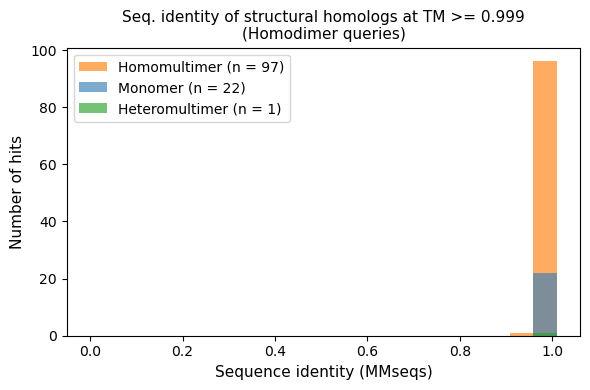

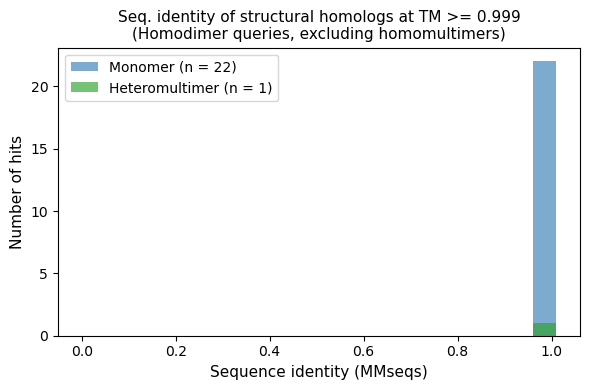


Homodimer queries with monomer structural homologs at TM >= 0.999 (17 unique pairs from 9 queries):


,query_pdb,target_pdb,tm_score,fident
0,7ban,7bao,0.9999,0.985
1,8eei,8eel,0.9998,1.000
2,9vlf,9l6j,0.9998,1.000
3,7y3w,7y3x,0.9997,0.997
4,8jyb,9lnz,0.9996,1.000
5,8jyb,9ln2,0.9996,1.000
6,8eei,8eej,0.9996,0.997
7,8eei,8een,0.9996,0.995
8,9grw,9gv9,0.9994,1.000
9,9rfy,9rg3,0.9993,1.000


\begin{longtable}{llrrl}
\caption{Foldseek structural homologs at TM-score $\geq 0.999$ with MMseqs
  sequence identity (fident), excluding homomultimer targets. One row per unique
  query--target PDB pair (best TM-score kept); fident is the maximum sequence identity
  found by MMseqs for that PDB pair (\texttt{---} if not found in MMseqs results).} \\
\label{supp:tab:foldseek_high_tm} \\
\toprule
Query & Target assembly & TM-score & Fident & Stoichiometry \\
\midrule
\endfirsthead
\toprule
Query & Target assembly & TM-score & Fident & Stoichiometry \\
\midrule
\endhead
\midrule
\multicolumn{5}{r}{\textit{Continued on next page}} \\
\endfoot
\bottomrule
\endlastfoot
9htw & 9i7w-assembly1 & 1.000 & 1.000 & heteromultimer \\
7ban & 7bao-assembly1 & 1.000 & 0.985 & monomer \\
8eei & 8eel-assembly2 & 1.000 & 1.000 & monomer \\
9vlf & 9l6j-assembly1 & 1.000 & 1.000 & monomer \\
7y3w & 7y3x-assembly1 & 1.000 & 0.997 & monomer \\
7y3w & 7y3x-assembly2 & 1.000 & 0.997 & monomer \\
8eei & 8eej-

In [20]:
# ── Supplementary table: Foldseek structural homologs at TM ≥ 0.99, with MMseqs seq. identity ──
# Addresses reviewer question on Fig. 3A: at TM-score ≈ 1, ~80% of structural
# homologs of homodimers are homomultimers and ~20% are monomers.
# This cell cross-references Foldseek TM-score hits with MMseqs sequence identity
# to show (1) a summary table, (2) fident distribution, and (3) concrete examples.
# Prerequisites: cells 11–12 (Foldseek data) and cell 17 (MMseqs data) must be run first.

TM_THRESHOLD = 0.999  # highest cutoff in _fracs_df; corresponds to reviewer's 'TM-score = 1'

# ── Collect Foldseek hits at TM ≥ TM_THRESHOLD for all dataset categories ─────────
_sup_rows = []
for (_pdb, _chain), _queries in _representative.items():
    _info    = _pdb_to_info[(_pdb, _chain)]
    _excl_pb = _queries[0].split('-')[0].lower()  # self-hit PDB to exclude
    # Combine hits from all chain queries; keep best TM per target assembly.
    _best_by_asm = {}
    for _q in _queries:
        for _, _h in _grouped[_q].iterrows():
            _tm     = _h['tm_score']
            _target = str(_h['target'])
            _t_pdb  = _target.split('-')[0].lower()
            if _t_pdb == _excl_pb or not (pd.notna(_tm) and float(_tm) >= TM_THRESHOLD):
                continue
            _asm  = _assembly_base(_target)
            _tm_f = float(_tm)
            if _asm not in _best_by_asm or _tm_f > _best_by_asm[_asm]['tm_score']:
                _best_by_asm[_asm] = {'target': _target, 't_pdb': _t_pdb, 'tm_score': _tm_f}
    for _asm, _hit in _best_by_asm.items():
        _st = _stoich_label(_hit['target'])
        if _st == 'unknown':
            continue
        _sup_rows.append({
            'category':        _info['category'],
            'max_rc':          _info['max_rc'],
            'query_pdb':       _pdb,
            'target_pdb':      _hit['t_pdb'],
            'target_assembly': _asm,
            'tm_score':        _hit['tm_score'],
            'stoich':          _st,
            'fident':          _fi_lookup.get((_pdb, _hit['t_pdb']), float('nan')),
        })

_sup_df = pd.DataFrame(_sup_rows)
print(f'Foldseek hits at TM >= {TM_THRESHOLD}: {len(_sup_df)} hits '
      f'({_sup_df["fident"].notna().sum()} with MMseqs seq. identity)', flush=True)

# ── Summary table: fraction and seq. identity per category × stoichiometry ───────
_CAT_LBL = {'homodimer': 'Homodimers', 'monomer': 'Monomers',
            'duplicated_heterodimer_chain': 'Heteromers'}
_ST_LBL  = {'monomer': 'Monomer', 'homomultimer': 'Homomultimer',
            'heteromultimer': 'Heteromultimer'}

_tbl_rows = []
for _cat in ['homodimer', 'monomer', 'duplicated_heterodimer_chain']:
    _sub = _sup_df[_sup_df['category'] == _cat]
    if _sub.empty:
        continue
    _n_total = len(_sub)
    for _st in STOICH_TYPES:
        _ss   = _sub[_sub['stoich'] == _st]
        _fi_v = _ss['fident'].dropna()
        _tbl_rows.append({
            'Category':        _CAT_LBL.get(_cat, _cat),
            'Stoichiometry':   _ST_LBL[_st],
            'Fraction':        round(len(_ss) / _n_total, 3),
            'N hits':          len(_ss),
            'Median seq. id.': round(_fi_v.median(), 3) if len(_fi_v) > 0 else float('nan'),
            'Mean seq. id.':   round(_fi_v.mean(),   3) if len(_fi_v) > 0 else float('nan'),
        })

_tbl_df = pd.DataFrame(_tbl_rows)
print(f'\nSupplementary Table — stoichiometry of structural homologs at TM >= {TM_THRESHOLD}:')
display(_tbl_df)

# ── Sequence identity distribution (homodimer queries) ────────────────────────────
_hom_plot = _sup_df[
    (_sup_df['category'] == 'homodimer') &
    _sup_df['fident'].notna()
]

_fig_si, _ax_si = plt.subplots(figsize=(6, 4))
for _st, _col in [('homomultimer',  STOICH_COLORS['homomultimer']),
                  ('monomer',        STOICH_COLORS['monomer']),
                  ('heteromultimer', STOICH_COLORS['heteromultimer'])]:
    _d = _hom_plot[_hom_plot['stoich'] == _st]['fident']
    if len(_d):
        _ax_si.hist(_d.values, bins=20, range=(0.0, 1.01), color=_col, alpha=0.65,
                    label=f'{_ST_LBL[_st]} (n = {len(_d)})')
_ax_si.set_xlabel('Sequence identity (MMseqs)', fontsize=11)
_ax_si.set_ylabel('Number of hits', fontsize=11)
_ax_si.set_title(f'Seq. identity of structural homologs at TM >= {TM_THRESHOLD}\n(Homodimer queries)',
                 fontsize=11)
_ax_si.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Sequence identity distribution (homodimer queries, excluding homomultimer targets) ──
# Same as above but restricted to non-homomultimer structural homologs, for comparison.
_hom_plot_no_hm = _hom_plot[_hom_plot['stoich'] != 'homomultimer']

_fig_si2, _ax_si2 = plt.subplots(figsize=(6, 4))
for _st, _col in [('monomer',        STOICH_COLORS['monomer']),
                  ('heteromultimer', STOICH_COLORS['heteromultimer'])]:
    _d = _hom_plot_no_hm[_hom_plot_no_hm['stoich'] == _st]['fident']
    if len(_d):
        _ax_si2.hist(_d.values, bins=20, range=(0.0, 1.01), color=_col, alpha=0.65,
                     label=f'{_ST_LBL[_st]} (n = {len(_d)})')
_ax_si2.set_xlabel('Sequence identity (MMseqs)', fontsize=11)
_ax_si2.set_ylabel('Number of hits', fontsize=11)
_ax_si2.set_title(f'Seq. identity of structural homologs at TM >= {TM_THRESHOLD}\n(Homodimer queries, excluding homomultimers)',
                  fontsize=11)
_ax_si2.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Examples: homodimer queries with monomer structural homologs at TM >= 0.99 ────
_mono_ex = (
    _sup_df[(_sup_df['category'] == 'homodimer') & (_sup_df['stoich'] == 'monomer')]
    .sort_values(['tm_score', 'fident'], ascending=[False, False])
    .drop_duplicates(subset=['query_pdb', 'target_pdb'])
    [['query_pdb', 'target_pdb', 'tm_score', 'fident']]
    .reset_index(drop=True)
)
print(f'\nHomodimer queries with monomer structural homologs at TM >= {TM_THRESHOLD} '
      f'({len(_mono_ex)} unique pairs from {_mono_ex["query_pdb"].nunique()} queries):')
display(_mono_ex)

# ── LaTeX table: best Foldseek hit per (query, target) PDB pair with fident ──────
# Duplicates in _sup_df arise because Foldseek matches the same target PDB code via
# multiple assemblies or chain variants (e.g. 9x4u-assembly1, 9x4u-assembly2).
# We keep only the highest TM-score hit per (query_pdb, target_pdb) pair.
# Homomultimer targets are excluded here to focus the table on the monomer /
# heteromultimer structural homologs.
_latex_df = (
    _sup_df[(_sup_df['category'] == 'homodimer') & (_sup_df['stoich'] != 'homomultimer')]
    [['query_pdb', 'target_assembly', 'tm_score', 'fident', 'stoich']]
    .sort_values('tm_score', ascending=False)
    .drop_duplicates(subset=['query_pdb', 'target_assembly'], keep='first')
    .reset_index(drop=True)
)

def _fmt(v, decimals=3):
    if pd.isna(v):
        return '---'
    return f'{v:.{decimals}f}'

_lines = [
    r'\begin{longtable}{llrrl}',
    r'\caption{Foldseek structural homologs at TM-score $\geq ' + str(TM_THRESHOLD) + r'$ with MMseqs',
    r'  sequence identity (fident), excluding homomultimer targets. One row per unique',
    r'  query--target PDB pair (best TM-score kept); fident is the maximum sequence identity',
    r'  found by MMseqs for that PDB pair (\texttt{---} if not found in MMseqs results).} \\',
    r'\label{supp:tab:foldseek_high_tm} \\',
    r'\toprule',
    r'Query & Target assembly & TM-score & Fident & Stoichiometry \\',
    r'\midrule',
    r'\endfirsthead',
    r'\toprule',
    r'Query & Target assembly & TM-score & Fident & Stoichiometry \\',
    r'\midrule',
    r'\endhead',
    r'\midrule',
    r'\multicolumn{5}{r}{\textit{Continued on next page}} \\',
    r'\endfoot',
    r'\bottomrule',
    r'\endlastfoot',
]
for _, _r in _latex_df.iterrows():
    _lines.append(
        f'{_r["query_pdb"]} & {_r["target_assembly"]} & {_fmt(_r["tm_score"])} & {_fmt(_r["fident"])} & {_r["stoich"]} \\\\'
    )
_lines.append(r'\end{longtable}')

_latex_str = '\n'.join(_lines)
print(_latex_str)
print(f'\n% {len(_latex_df)} unique (query, target) pairs after deduplication (homomultimers excluded)')


In [21]:
# ── Percentage breakdown matching figure values ───────────────────────────────
for _thresh, _label in [(0.2, '<= 0.2'), (0.8, '>= 0.8'), (0.9, '>= 0.9'), (0.999, '>= 0.999'), (1.0, '= 1.0')]:
    _cut_df = _fracs_df[_fracs_df['tm_cutoff'] == _thresh]
    print(f'\nStoichiometry breakdown at TM-score {_label}:')
    for _cat in ['homodimer', 'monomer', 'duplicated_heterodimer_chain']:
        _c = _cut_df[_cut_df['category'] == _cat]
        if _c.empty:
            print(f'  {_CAT_LBL[_cat]}: no hits')
            continue
        _n_queries = len(_c[_c['stoich'] == STOICH_TYPES[0]])
        print(f'  {_CAT_LBL[_cat]} ({_n_queries} queries with hits):')
        for _st in STOICH_TYPES:
            _mean_frac = _c[_c['stoich'] == _st]['frac'].mean()
            print(f'    {100*_mean_frac:.1f}%  {_ST_LBL[_st]}')



Stoichiometry breakdown at TM-score <= 0.2:
  Homodimers (712 queries with hits):
    25.4%  Monomer
    48.1%  Homomultimer
    26.5%  Heteromultimer
  Monomers (775 queries with hits):
    36.1%  Monomer
    29.7%  Homomultimer
    34.1%  Heteromultimer
  Heteromers (562 queries with hits):
    25.5%  Monomer
    24.4%  Homomultimer
    50.1%  Heteromultimer

Stoichiometry breakdown at TM-score >= 0.8:
  Homodimers (633 queries with hits):
    22.9%  Monomer
    67.3%  Homomultimer
    9.8%  Heteromultimer
  Monomers (538 queries with hits):
    73.8%  Monomer
    15.9%  Homomultimer
    10.3%  Heteromultimer
  Heteromers (429 queries with hits):
    28.8%  Monomer
    6.9%  Homomultimer
    64.3%  Heteromultimer

Stoichiometry breakdown at TM-score >= 0.9:
  Homodimers (547 queries with hits):
    20.2%  Monomer
    71.6%  Homomultimer
    8.2%  Heteromultimer
  Monomers (421 queries with hits):
    82.9%  Monomer
    11.7%  Homomultimer
    5.4%  Heteromultimer
  Heteromers (316 q

## Table 2: Trying different MSA settings

In [22]:
# MSA csvs: 
one_taxid_csv = "/proj/berzelius-2021-29/users/x_sarna/homomer_project/new_dataset/diff_msa_settings_runs/results_1_from_each_taxid.csv"
evalue_csv = "/proj/berzelius-2021-29/users/x_sarna/homomer_project/new_dataset/diff_msa_settings_runs/results_evalue_10-60_1iter.csv"

In [23]:
# ── Table: MSA settings comparison ────────────────────────────────────────────
CATEGORICAL_COLS_MSA = {
    "ID", "highest_match_all_hits", "highest_match_multimers",
    "highest_match_homomultimers", "stoich_all_hits", "stoich_multimers", "category",
}

def load_msa_csv(path):
    df = pd.read_csv(path, keep_default_na=False)
    for col in df.columns:
        if col not in CATEGORICAL_COLS_MSA:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

df_one_taxid = load_msa_csv(one_taxid_csv)
df_evalue    = load_msa_csv(evalue_csv)

MSA_SETTINGS = [
    (r"E-Value==$10^{-1}$, 3 iterations (Default)", DATASETS["homodimers"]),
    (r"E-Value==$10^{-60}$, 1 iteration",            df_evalue),
    (r"Orthologs (1 Seq Per TaxID)",                 df_one_taxid),
]

col = "max_rc"
msa_rows = []
for label, df_s in MSA_SETTINGS:
    vals = df_s[[col, "correct_result"]].dropna()
    y_true, y_pred = vals["correct_result"].values, vals[col].values
    prec, rec, _ = precision_recall_curve(y_true, y_pred)
    aupr          = auc(rec, prec)
    f1, mcc       = get_f1_mcc(y_true, y_pred, threshold=0.8)
    tpr_5, _      = get_tpr_at_fpr(y_true, y_pred, target_fpr=0.05)
    tpr_1, _      = get_tpr_at_fpr(y_true, y_pred, target_fpr=0.01)
    msa_rows.append((label, aupr, f1, mcc, tpr_5, tpr_1))

# ── Plain-text sanity check ───────────────────────────────────────────────────
hdr = f"{'MSA Setting':<48} {'AUPR':>6}  {'F1@0.8':>7}  {'MCC@0.8':>8}  {'TPR@5%FPR':>10}  {'TPR@1%FPR':>10}"
print(hdr)
print("-" * len(hdr))
for name, aupr, f1, mcc, tpr5, tpr1 in msa_rows:
    print(f"{name:<48} {aupr:>6.3f}  {f1:>7.3f}  {mcc:>8.3f}  {tpr5:>10.3f}  {tpr1:>10.3f}")

# ── LaTeX table ───────────────────────────────────────────────────────────────
print()
print(r"\begin{table*}")
print(r"\begin{center}")
print(r"\caption{Area under the precision-recall curve (AUPR), F1-score and MCC-score for the different MSA settings. The thresholds for F1 and MCC are 0.8. All measured targets are scored by the maximum ranking confidence across all 25 models generated.  \label{tab:msa_settings}}")
print(r"\begin{threeparttable}")
print(r"\begin{tabular}{lcccrr}")
print(r"\headrow")
print(r"MSA Setting & AUPR ($\uparrow$) & F1 ($\uparrow$) & MCC ($\uparrow$) & TPR@5\%FPR ($\uparrow$) & TPR@1\%FPR ($\uparrow$)  \\")
for name, aupr, f1, mcc, tpr5, tpr1 in msa_rows:
    print(f"{name}  & {aupr:.2f} & {f1:.2f} & {mcc:.2f} & {tpr5:.2f} & {tpr1:.2f} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{threeparttable}")
print(r"\end{center}")
print(r"\end{table*}")

MSA Setting                                        AUPR   F1@0.8   MCC@0.8   TPR@5%FPR   TPR@1%FPR
--------------------------------------------------------------------------------------------------
E-Value==$10^{-1}$, 3 iterations (Default)        0.789    0.726     0.607       0.587       0.221
E-Value==$10^{-60}$, 1 iteration                  0.612    0.429     0.395       0.356       0.214
Orthologs (1 Seq Per TaxID)                       0.793    0.736     0.625       0.591       0.223

\begin{table*}
\begin{center}
\caption{Area under the precision-recall curve (AUPR), F1-score and MCC-score for the different MSA settings. The thresholds for F1 and MCC are 0.8. All measured targets are scored by the maximum ranking confidence across all 25 models generated.  \label{tab:msa_settings}}
\begin{threeparttable}
\begin{tabular}{lcccrr}
\headrow
MSA Setting & AUPR ($\uparrow$) & F1 ($\uparrow$) & MCC ($\uparrow$) & TPR@5\%FPR ($\uparrow$) & TPR@1\%FPR ($\uparrow$)  \\
E-Value==$10^{-1}$,